# W&B Experiment Analysis
Basic utilities to load runs from Weights & Biases and plot metrics.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from scipy.interpolate import make_interp_spline
import numpy as np
from dotenv import load_dotenv
import os
import zipfile
import re
from collections import defaultdict

load_dotenv()
api_key = os.environ.get("WANDB_KEY")
wandb.login(key=api_key)
api = wandb.Api(timeout=120)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/sdouka/.netrc
wandb: Currently logged in as: stella_douka (stella_douka-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## SetUp

In [2]:
def legend(ax1, ax2=None, extra_lines=[], extra_labels=[], loc=None, **kwargs):
    lines, labels = ax1.get_legend_handles_labels()
    if ax2 is not None:
        lines2, labels2 = ax2.get_legend_handles_labels()
    else:
        lines2, labels2 = [], []
    by_label = dict(zip(labels + labels2 + extra_labels, lines + lines2 + extra_lines))
    return plt.legend(by_label.values(), by_label.keys(), loc=loc, **kwargs)
    # plt.legend(lines + lines2, labels + labels2)

In [3]:
# plt.rcParams["mathtext.fontset"] = "stix"
# plt.rcParams["font.family"] = "STIXGeneral"
# plt.rcParams.update({"font.size": 14})

In [4]:
# cmap = plt.cm.get_cmap("tab10")
# cmap(0)

In [5]:
# Wong colorblind-friendly palette
wong_colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
]

In [6]:
# --- Global RC params ---
mpl.rcParams.update({
    # Figure
    "figure.figsize":        (3.5, 2.625),   # single-column (3.5") or double (7")
    # "figure.figsize":        (2.625, 2.625),
    "figure.dpi":            300,
    "figure.constrained_layout.use": True,   # better than tight_layout

    # Font — match your LaTeX font if possible
    "font.family":           "serif",
    "font.serif":            ["Times New Roman", "DejaVu Serif"],
    "font.size":             8,              # base size; scale everything from here
    "axes.titlesize":        9,
    "axes.labelsize":        8,
    "xtick.labelsize":       7,
    "ytick.labelsize":       7,
    "legend.fontsize":       7,
    "axes.titleweight":      "bold",

    # LaTeX rendering (optional but great for consistency with paper body)
    "text.usetex":           True,
    "text.latex.preamble":   r"\usepackage{times}\usepackage{amsmath}",

    # Lines & markers
    "lines.linewidth":       1.0,
    "lines.markersize":      3.0,

    # Axes
    "axes.linewidth":        0.5,
    "axes.spines.top":       False,          # cleaner look
    "axes.spines.right":     False,
    "axes.grid":             True,
    "grid.linewidth":        0.4,
    "grid.alpha":            0.4,
    "grid.linestyle":        "--",

    # Ticks
    "xtick.major.width":     0.5,
    "ytick.major.width":     0.5,
    "xtick.major.size":      3,
    "ytick.major.size":      3,
    "xtick.direction":       "in",
    "ytick.direction":       "in",

    # Legend
    "legend.framealpha":     0.8,
    "legend.edgecolor":      "0.8",
    "legend.borderpad":      0.4,
    "legend.handlelength":   1.5,

    # Saving
    "savefig.dpi":           300,
    "savefig.bbox":          "tight",
    "savefig.pad_inches":    0.02,
    "pdf.fonttype":          42,             # embeds fonts properly — important for camera-ready
    "ps.fonttype":           42,

    # Darkgrid
    "axes.facecolor":  "#EAEAF2",
    "grid.color":      "white",
    "grid.linewidth":  0.8,
    "grid.alpha":      1.0,
    "grid.linestyle":  "-",
    "axes.grid":       True,
})

## Configuration

In [8]:
ENTITY = None   # wandb entity (username or team), None = default
PROJECT = "SmallBenchmarks"  # wandb project name

## Loading functions

In [9]:
def load_runs(project, entity=None, filters=None, tags=None,
              state=None, min_duration=None, max_duration=None,
              config=None, summary=None):
    """Load runs from a W&B project with flexible filtering.

    Parameters
    ----------
    project : str
        W&B project name.
    entity : str, optional
        W&B entity (username or team). Uses default if None.
    filters : dict, optional
        Raw MongoDB-style filter dict merged with all other filters.
    tags : list[str], optional
        Only return runs that have ALL of these tags.
    state : str, optional
        Run state: 'finished', 'running', 'crashed', 'failed'.
    min_duration : float, optional
        Minimum run duration in seconds.
    max_duration : float, optional
        Maximum run duration in seconds.
    config : dict, optional
        Config key-value requirements, e.g. {'lr': 0.01, 'seed': 2}.
        Supports comparison operators via dict values:
        {'lr': {'$gt': 0.001, '$lt': 0.1}}.
    summary : dict, optional
        Summary metric requirements (same format as config).
        e.g. {'val/accuracy': {'$gt': 0.9}}.

    Returns
    -------
    list[wandb.Run]
    """
    path = f"{entity}/{project}" if entity else project
    _filters = dict(filters or {})

    if tags:
        _filters["tags"] = {"$all": tags}
    if state:
        _filters["state"] = state
    if min_duration is not None or max_duration is not None:
        dur = {}
        if min_duration is not None:
            dur["$gte"] = min_duration
        if max_duration is not None:
            dur["$lte"] = max_duration
        _filters["duration"] = dur
    for key, value in (config or {}).items():
        _filters[f"config.{key}"] = value
    for key, value in (summary or {}).items():
        _filters[f"summary_metrics.{key}"] = value

    runs = api.runs(path, filters=_filters or None)
    print(f"Found {len(runs)} runs in '{path}'")
    return list(runs)


def runs_to_summary_df(runs):
    """Build a DataFrame with one row per run (config + summary metrics).

    Parameters
    ----------
    runs : list[wandb.Run]

    Returns
    -------
    pd.DataFrame
    """
    records = []
    for run in runs:
        row = {
            "id": run.id,
            "name": run.name,
            "state": run.state,
            "tags": ", ".join(run.tags),
            "created_at": run.created_at,
            "duration_s": run.summary.get("_runtime", None),
        }
        row.update({f"config/{k}": v for k, v in run.config.items()
                    if not isinstance(v, (dict, list))})
        row.update({f"summary/{k}": v for k, v in run.summary.items()
                    if not isinstance(v, (dict, list)) and not k.startswith("_")})
        records.append(row)
    return pd.DataFrame(records)


def load_history(run, keys=None, samples=1000):
    """Load metric history for a single run as a DataFrame.

    Parameters
    ----------
    run : wandb.Run
    keys : list[str], optional
        Metric names to fetch. Fetches all if None.
    samples : int
        Max number of data points to retrieve.

    Returns
    -------
    pd.DataFrame
    """
    df = run.history(keys=keys, samples=samples, pandas=True)
    df["run_id"] = run.id
    df["run_name"] = run.name
    return df


def load_histories(runs, keys=None, samples=1000):
    """Load and concatenate history for multiple runs."""
    dfs = [load_history(r, keys=keys, samples=samples) for r in runs]
    return pd.concat(dfs, ignore_index=True)

## Grouping functions

In [10]:
def group_runs(runs, by):
    """Group runs by a config key, a tag substring, or run state.

    Parameters
    ----------
    runs : list[wandb.Run]
    by : str
        - Config key, e.g. ``'lr'`` → groups labelled ``'lr=0.01'`` etc.
        - ``'tag:<substr>'`` → groups by the first tag containing *substr*.
        - ``'state'`` → groups by run state (finished / crashed / running).
        - ``'name:<prefix_len>'`` → groups by the first N chars of the run name.

    Returns
    -------
    dict[str, list[wandb.Run]]
    """
    groups = {}
    for run in runs:
        if by.startswith("tag:"):
            substr = by[4:]
            label = next((t for t in run.tags if substr in t), "other")
        elif by == "state":
            label = run.state
        elif by.startswith("name:"):
            n = int(by[5:])
            label = run.name[:n]
        else:
            val = run.config.get(by, "N/A")
            label = f"{by}={val}"
        groups.setdefault(label, []).append(run)
    for label, grp in groups.items():
        print(f"  {label!r}: {len(grp)} run(s)")
    return groups

In [11]:
def plot_metric_grouped(groups, metric, x="_step", smooth=0, ax=None, title=None, n_points=300):
    """Plot mean ± std band per group of runs.

    Parameters
    ----------
    groups : dict[str, list[wandb.Run]]
        Output of group_runs().
    metric : str
    x : str
        X-axis column (e.g. '_step', 'epoch').
    smooth : int
        Smoothing window applied to mean and std after interpolation.
    ax : matplotlib.Axes, optional
    title : str, optional
    n_points : int
        Resolution of the interpolation grid.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    colors = cm.tab10(np.linspace(0, 1, max(len(groups), 1)))
    for (label, runs), color in zip(groups.items(), colors):
        series, x_min, x_max = [], np.inf, -np.inf
        for run in runs:
            # df = load_history(run, keys=[x, metric] if x != "_step" else [metric])
            df = pd.DataFrame(run)
            if metric not in df.columns:
                continue
            df = df.dropna(subset=[metric])
            xs = df[x].values if x in df.columns else df.index.values
            if len(xs) < 2:
                continue
            x_min = min(x_min, xs[0])
            x_max = max(x_max, xs[-1])
            series.append((xs, df[metric].values))
        if not series:
            continue
        grid = np.linspace(x_min, x_max, n_points)
        interp = np.array([np.interp(grid, xs, ys) for xs, ys in series])
        mean, std = interp.mean(axis=0), interp.std(axis=0)
        if smooth > 1:
            kernel = np.ones(smooth) / smooth
            mean = np.convolve(mean, kernel, mode="same")
            std  = np.convolve(std,  kernel, mode="same")
        ax.plot(grid, mean, label=f"{label} (n={len(series)})", color=color)
        ax.fill_between(grid, mean - std, mean + std, alpha=0.2, color=color)
    ax.set_xlabel(x)
    ax.set_ylabel(metric)
    ax.set_title(title or metric)
    ax.legend(fontsize=8)
    return ax


def plot_metrics_grouped(groups, metrics, x="_step", smooth=0, ncols=2, n_points=300):
    """Grid of grouped metric plots (mean ± std per group)."""
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for ax, metric in zip(axes, metrics):
        plot_metric_grouped(groups, metric, x=x, smooth=smooth, ax=ax, n_points=n_points)
    for ax in axes[len(metrics):]:
        ax.set_visible(False)
    fig.tight_layout()
    return fig


def plot_summary_bar_grouped(df, metric_col, group_col, hue_col="name", ax=None, title=None):
    """Grouped bar chart: one cluster of bars per group_col value, one bar per hue_col.

    Parameters
    ----------
    df : pd.DataFrame
        Output of runs_to_summary_df().
    metric_col : str
        Column with the value to plot (e.g. 'summary/val/accuracy').
    group_col : str
        Column defining bar clusters (x-axis groups).
    hue_col : str
        Column defining bars within each cluster.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    sub = df[[group_col, hue_col, metric_col]].dropna()
    groups = sub[group_col].unique()
    hues   = sub[hue_col].unique()
    n_g, n_h = len(groups), len(hues)
    width = 0.8 / n_h
    colors = cm.tab10(np.linspace(0, 1, max(n_h, 1)))
    for i, (hue, color) in enumerate(zip(hues, colors)):
        mask = sub[hue_col] == hue
        vals = [sub.loc[mask & (sub[group_col] == g), metric_col].mean() for g in groups]
        offsets = np.arange(n_g) + (i - n_h / 2 + 0.5) * width
        ax.bar(offsets, vals, width=width * 0.9, label=str(hue), color=color)
    ax.set_xticks(np.arange(n_g))
    ax.set_xticklabels(groups, rotation=30, ha="right")
    ax.set_ylabel(metric_col)
    ax.set_title(title or f"{metric_col} by {group_col}")
    ax.legend(title=hue_col, fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    return ax

In [12]:
def plot_metric(runs, metric, x="_step", smooth=0, ax=None, title=None):
    """Plot one metric over training steps for each run.

    Parameters
    ----------
    runs : list[wandb.Run]
    metric : str
        Name of the metric column to plot.
    x : str
        Column to use as x-axis (e.g. '_step', 'epoch').
    smooth : int
        Rolling-average window (0 = no smoothing).
    ax : matplotlib.Axes, optional
    title : str, optional
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    colors = cm.tab10(np.linspace(0, 1, max(len(runs), 1)))
    for run, color in zip(runs, colors):
        df = load_history(run, keys=[x, metric] if x != "_step" else [metric])
        if metric not in df.columns:
            print(f"  '{metric}' not found in run {run.name!r}, skipping.")
            continue
        df = df.dropna(subset=[metric])
        y = df[metric]
        xs = df[x] if x in df.columns else df.index
        if smooth > 1:
            ax.plot(xs, y, alpha=0.2, color=color)
            y = y.rolling(smooth, min_periods=1).mean()
        ax.plot(xs, y, label=run.name, color=color)
    ax.set_xlabel(x)
    ax.set_ylabel(metric)
    ax.set_title(title or metric)
    ax.legend(fontsize=8)
    return ax


def plot_metrics(runs, metrics, x="_step", smooth=0, ncols=2):
    """Grid of plots, one subplot per metric.

    Parameters
    ----------
    runs : list[wandb.Run]
    metrics : list[str]
    x : str
    smooth : int
    ncols : int
        Number of columns in the subplot grid.
    """
    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for ax, metric in zip(axes, metrics):
        plot_metric(runs, metric, x=x, smooth=smooth, ax=ax)
    for ax in axes[len(metrics):]:
        ax.set_visible(False)
    fig.tight_layout()
    return fig


def plot_summary_bar(df, metric_col, group_col="name", ax=None, title=None):
    """Bar chart of a summary metric across runs.

    Parameters
    ----------
    df : pd.DataFrame
        Output of runs_to_summary_df().
    metric_col : str
        Column name (e.g. 'summary/val/accuracy').
    group_col : str
        Column to use as bar labels.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(max(6, len(df) * 0.6), 4))
    sub = df[[group_col, metric_col]].dropna()
    ax.bar(sub[group_col], sub[metric_col])
    ax.set_xlabel(group_col)
    ax.set_ylabel(metric_col)
    ax.set_title(title or metric_col)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    return ax

def plot_metric_vs_metric(runs, x_metric, y_metric, color_by=None,
                          source="history", samples=500, ax=None, title=None):
    """Scatter plot of one metric against another.

    Works in two modes:
    - ``source='history'``: scatter each logged step (x_metric vs y_metric
      from the run's time-series history).
    - ``source='summary'``: one point per run using final summary values.
      Pass a summary DataFrame as *runs* in this mode.

    Parameters
    ----------
    runs : list[wandb.Run] or pd.DataFrame
        Runs to plot, or a summary DataFrame (when source='summary').
    x_metric : str
        Column name for the x-axis.
    y_metric : str
        Column name for the y-axis.
    color_by : str, optional
        Column used to color points (config key or 'run_name').
        When source='history', must be a column present in the history df.
        When source='summary', must be a column in the summary df.
    source : {'history', 'summary'}
    samples : int
        Max history samples per run (only used when source='history').
    ax : matplotlib.Axes, optional
    title : str, optional
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    if source == "summary":
        # runs is actually a summary DataFrame here
        df = runs if isinstance(runs, pd.DataFrame) else runs_to_summary_df(runs)
        sub = df[[x_metric, y_metric] + ([color_by] if color_by else [])].dropna(subset=[x_metric, y_metric])
        if color_by:
            categories = sub[color_by].unique()
            colors = cm.tab10(np.linspace(0, 1, max(len(categories), 1)))
            for cat, color in zip(categories, colors):
                mask = sub[color_by] == cat
                ax.scatter(sub.loc[mask, x_metric], sub.loc[mask, y_metric],
                           label=str(cat), color=color, alpha=0.8)
            ax.legend(title=color_by, fontsize=8)
        else:
            ax.scatter(sub[x_metric], sub[y_metric], alpha=0.8)

    else:  # history
        all_dfs = load_histories(runs, keys=[x_metric, y_metric] + ([color_by] if color_by and color_by not in ("run_name", "run_id") else []), samples=samples)
        all_dfs = all_dfs.dropna(subset=[x_metric, y_metric])
        group_col = color_by if color_by else "run_name"
        if group_col not in all_dfs.columns:
            group_col = "run_name"
        categories = all_dfs[group_col].unique()
        colors = cm.tab10(np.linspace(0, 1, max(len(categories), 1)))
        for cat, color in zip(categories, colors):
            mask = all_dfs[group_col] == cat
            ax.scatter(all_dfs.loc[mask, x_metric], all_dfs.loc[mask, y_metric],
                       label=str(cat), color=color, alpha=0.5, s=10)
        ax.legend(title=group_col, fontsize=7, markerscale=2)

    ax.set_xlabel(x_metric)
    ax.set_ylabel(y_metric)
    ax.set_title(title or f"{y_metric} vs {x_metric}")
    return ax

In [13]:
def group_df(runs, by='group', filter_df=None):
    groups = {}
    for run in runs:
        if filter_df is not None:
            if run.id not in filter_df["run_id"].values:
                continue
        if by == "group":
            group = run.group
        else:
            group = run.config.get(by)
        # if group is None:
        #     group = "growth"
        groups.setdefault(group, []).append(run)
    return groups

# group_df(df, "group")["PC-DARTS"][0]["summary/search/val accuracy"]

In [14]:
def _fmt_runtime(seconds: float, _) -> str:
    seconds = int(seconds)
    h, rem = divmod(seconds, 3600)
    m, s = divmod(rem, 60)
    if h > 0:
        return f"{h}h{m:02d}m"
    if m > 0:
        return f"{m}m{s:02d}s"
    return f"{s}s"

In [15]:
def _fmt_params(params: float, _) -> str:
    return f"{params/1e6:.1f}"

In [16]:
def extract_memory_data(runs, all_metrics=False, all_config=False):
    data = []
    for run in runs:
        if "dataset" in run.config and run.config["dataset"] == "addnist":
            continue
        history = run.history(stream="events")  # system metrics are in the events stream
        gpu_cols = [c for c in history.columns if "memoryAllocatedBytes" in c and "process" in c.lower()]
        if len(gpu_cols) < 1:
            gpu_cols = [c for c in history.columns if "memoryAllocatedBytes" in c]
        if len(gpu_cols) < 1:
            gpu_cols.append(None)
        for col in gpu_cols:
            row = {
                "group": run.group,
                "model": run.config["model"] if "model" in run.config else "",
                "dataset": run.config["dataset"] if "dataset" in run.config else run.config["dataset.name"],
                "run_id": run.id,
                "run_name": run.name,
                "metric": col,
                "mean allocation (bytes)": history[col].mean() if col is not None else None,
                "max allocation (bytes)": history[col].max() if col is not None else None,
                "mean allocation (GB)": history[col].mean() * 1e-9 if col is not None else None,
                "max allocation (GB)": history[col].max() * 1e-9 if col is not None else None,
                "GPU hours": run.summary["_runtime"] / 3600,
            }
            if all_config:
                row.update({f"config/{k}": v for k, v in run.config.items()
                        if not isinstance(v, (dict, list))})
            if all_metrics:
                row.update({f"summary/{k}": v for k, v in run.summary.items()
                            if not isinstance(v, (dict, list)) and not k.startswith("_")})
            data.append(row)
    return data

## Plotting functions

In [17]:
def plot_metrics_with_ci(
    grouped: dict[str, list],
    metric_keys: list[str],
    ax = None,
    ci: float = 0.95,
    smooth_window: int = 1,
    step_key: str = "_step",
    figsize: tuple = (8, 4),
):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    z = {0.90: 1.645, 0.95: 1.960, 0.99: 2.576}.get(ci, 1.960)

    # Single history call per run
    group_histories: dict[str, dict[str, list]] = {}
    for group_name, runs in grouped.items():
        group_name = str(group_name)
        histories = {k: [] for k in metric_keys}
        for run in runs:
            for metric_key in metric_keys:
                hist = run.history(keys=[step_key, "_runtime", metric_key], pandas=True)
                if metric_key not in hist.columns:
                    # print(run.name, run.group, metric_key)
                    continue
                s = hist.dropna(subset=[metric_key]).set_index("_runtime")[metric_key]
                if not s.empty:
                    histories[metric_key].append(s)
        group_histories[group_name] = histories

    # One color per (group, metric) pair
    pairs = [(str(g), m) for g in grouped for m in metric_keys]
    for idx, (group_name, metric_key) in enumerate(pairs):
        color = colors[group_name.split("-continue")[0]]
        series_list = group_histories[group_name][metric_key]

        if not series_list:
            continue

        plot_ci(ax, series_list, group_name, smooth_window, z, color)
    
    ax.axvline(10_800, color='k', linestyle="--")
    ax.axvline(21_600, color='k', linestyle="--")

    legend(ax, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_runtime))
    ax.set_xticks(np.arange(0, 21_600+1, step=3_600))
    ax.set_xlabel("GPU hours")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(top=100)
    ax.set_xlim(left=0)
    fig.tight_layout()
    # fig.show()
    return fig, ax

In [18]:
def plot_ci(ax, series_list, group_name, smooth_window=1, z=1.960, color="k", linestyle="-"):
    combined = (
        series_list[0].to_frame()
        .join([s.rename(f"r{i}") for i, s in enumerate(series_list[1:], 1)], how="outer")
        .sort_index()
        .interpolate(method="index")
    )
    combined.columns = [f"r{i}" for i in range(len(series_list))]

    steps = combined.index.to_numpy()
    values = combined.to_numpy() * 100

    if "continue" in group_name:
        steps += 10_800

    mean = np.nanmean(values, axis=1)
    sem = np.nanstd(values, axis=1, ddof=1) / np.sqrt(
        np.sum(~np.isnan(values), axis=1).clip(1)
    )
    lo, hi = mean - z * sem, mean + z * sem

    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        mean = np.convolve(mean, kernel, mode="same")
        lo   = np.convolve(lo,   kernel, mode="same")
        hi   = np.convolve(hi,   kernel, mode="same")
        # trim edges
        half = smooth_window // 2
        steps, mean = steps[half:-half], mean[half:-half]
        lo, hi = lo[half:-half], hi[half:-half]
    
    # if len(steps) > 3:
    #     # Spline over a uniform index, not the parameter count
    #     idx = np.arange(len(steps))
    #     idx_dense = np.linspace(0, len(steps) - 1, 500)

    #     mean = make_interp_spline(idx, mean, k=3)(idx_dense)
    #     lo   = make_interp_spline(idx, lo,   k=3)(idx_dense)
    #     hi   = make_interp_spline(idx, hi,   k=3)(idx_dense)
    #     steps = np.interp(idx_dense, idx, steps)  # map dense idx back to param counts

    # n_runs = values.shape[1]
    # label = f"{group_name} - {metric_key} (n={n_runs})"
    label = f"{group_name.split('-continue')[0]}"
    ax.plot(steps, mean, label=label, color=color, linestyle=linestyle, linewidth=1.4)
    ax.fill_between(steps, lo, hi, alpha=0.18, color=color)

def plot_metrics_with_ci_step(
    grouped: dict[str, list],
    metric_keys: list[str],
    step: str = "epoch",
    ax = None,
    ci: float = 0.95,
    smooth_window: int = 1,
    step_key: str = "_step",
    figsize: tuple = (8, 4),
    logscale: bool = False,
    title: str = "",
):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    z = {0.90: 1.645, 0.95: 1.960, 0.99: 2.576}.get(ci, 1.960)

    linestyles = ["-", "--", "-.", ":"]

    # Single history call per run
    group_histories: dict[str, dict[str, list]] = {}
    for group_name, runs in grouped.items():
        group_name = str(group_name)
        histories = {k: [] for k in metric_keys}
        for run in runs:
            for metric_key in metric_keys:
                # hist = run.history(keys=[step_key, step, metric_key], pandas=True)
                hist_metric = run.history(keys=[step_key, metric_key], pandas=True)
                hist_step   = run.history(keys=[step_key, step], pandas=True)

                hist = hist_metric.merge(hist_step, on=step_key, how="outer").sort_values(step_key)
                hist[step] = hist[step].ffill()
                hist = hist.dropna(subset=[metric_key])
                
                # print(hist_metric.head())
                # print(hist_step.head())
                # print(hist.head())
                # print()

                if metric_key not in hist.columns:
                    # print(run.name, run.group, metric_key)
                    continue
                s = hist.dropna(subset=[metric_key]).set_index(step)[metric_key]
                if not s.empty:
                    histories[metric_key].append(s)
        group_histories[group_name] = histories

    # One color per (group, metric) pair
    pairs = [(str(g), m) for g in grouped for m in metric_keys]
    for idx, (group_name, metric_key) in enumerate(pairs):
        color = colors[group_name.split("-continue")[0]]
        series_list = group_histories[group_name][metric_key]

        if not series_list:
            continue

        plot_ci(ax, series_list, group_name, smooth_window, z, color, linestyle=linestyles[idx%len(pairs)])

    # legend(ax, frameon=False)
    ax.set_title(title, fontweight="bold", pad=4)

    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

    ax.set_xlabel(step)
    ax.set_ylabel("accuracy")

    if logscale:
        ax.set_xscale('log')
    return fig, ax

In [19]:
def add_box(ax, groups, pos=None, width=1_000, metric="training/test accuracy"):
    myHandle = []

    for group, runs in groups.items():
        print(group)
        final_values = []
        x_pos = []
        for run in runs:
            if isinstance(run, wandb.apis.public.runs.Run):
                if (metric not in run.summary) or (pos is not None and pos not in run.summary):
                    continue
                final_values.append(run.summary.get(metric) * 100)
                if pos is not None:
                    x_pos.append(run.summary.get(pos))
            elif isinstance(run, pd.DataFrame):
                if (metric not in run.columns) or (pos is not None and pos not in run.columns):
                    continue
                final_values.append(run[metric].dropna().values[-1] * 100)
                if pos is not None:
                    x_pos.append(run[pos].dropna().values[-1])
            else:
                continue
        
        if pos is None:
            x_pos = 10_800 + (10_800 if "continue" in group else 0) # just past the end of the x-axis
        else:
            print("Parameters:", x_pos)
            x_pos = np.mean(x_pos)
            print("Mean parameters:", x_pos)

        color = colors[group.split("-continue")[0]]
        print("Values:", final_values, "\n")
        
        box = ax.boxplot(
            final_values,
            positions=[x_pos],
            widths=width,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor=color, linewidth=1.2),
            medianprops=dict(color=color, linewidth=1.5),
            whiskerprops=dict(color=color, linewidth=1.2),
            capprops=dict(color=color, linewidth=1.5),
            flierprops=dict(marker="x", color=color, alpha=0.5, markersize=4),
            manage_ticks=False,  # don't let boxplot override x-axis ticks
            # whis=0.5,
        )
        box["boxes"][0].set_alpha(0.6)
        # plt.scatter([x_pos] * len(final_values), final_values, color=color, alpha=0.6, zorder=5)

        myHandle.append(
            Line2D([], [], 
                color=colors[group], 
                markersize=mpl.rcParams["lines.markersize"], linewidth=mpl.rcParams["lines.linewidth"], 
                linestyle="-"
            ),
        )
    keys = list(re.sub("restricted", "Demeter", k) for k in groups.keys())
    return myHandle, keys

In [56]:
def plot_metrics_with_ci_fin(
    grouped: dict[str, list],
    metric_keys: list[str],
    step: str = "epoch",
    ax=None,
    ci: float = 0.95,
    smooth_window: int = 1,
    step_key: str = "_step",
    logscale: bool = False,
    title: str = "",
    n_bins: int = 100,
    bin_max: float = 1e7,
    bin_size: float = 1e5,
    use_max: bool = True,
    use_cummax: bool = False,
    normalize_x: bool = False,
    guides: bool = True,
):
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()

    z = {0.90: 1.645, 0.95: 1.960, 0.99: 2.576}.get(ci, 1.960)
    if normalize_x:
        bins = np.linspace(0, 1, n_bins)
    else:
        bins = np.arange(0, bin_max + bin_size, bin_size)  # shape (B,)

    group_histories: dict[str, dict[str, list]] = {}
    for group_name, runs in grouped.items():
        group_name = str(group_name)
        histories = {k: [] for k in metric_keys}

        for run in runs:
            for metric_key in metric_keys:
                if isinstance(run, wandb.apis.public.runs.Run):
                    if metric_key not in run.summary:
                        continue
                    
                    hist_metric = run.history(keys=[step_key, metric_key], pandas=True)
                    hist_step   = run.history(keys=[step_key, step], pandas=True)
                    
                elif isinstance(run, pd.DataFrame):
                    if metric_key not in run.columns or step not in run.columns:
                        continue

                    run = run.reset_index()
                    hist_metric = run[[step_key, metric_key]]
                    hist_step   = run[list(set([step_key, step]))]
                
                # if step_key != step:
                hist = hist_metric.merge(hist_step, on=step_key, how="outer").sort_values(step_key)
                # else: 
                    # hist = hist_metric.sort_values(step_key)
                hist[step] = hist[step].ffill()
                hist = hist.dropna(subset=[metric_key, step])

                if metric_key not in hist.columns:
                    continue

                # --- keep only final accuracy per complexity value ---
                # last logged accuracy for each unique complexity
                if use_max:
                    final_per_complexity = hist.sort_values(step_key).groupby(step)[metric_key].max()  # final acc at each complexity
                else:
                    final_per_complexity = hist.sort_values(step_key).groupby(step)[metric_key].last()  # final acc at each complexity

                if normalize_x:
                    max_x = final_per_complexity.index.max()
                    final_per_complexity.index = final_per_complexity.index / max_x  # → [0, 1]

                
                max_complexity = final_per_complexity.index.max()

                # --- bin: for each bin edge, take last value <= bin edge ---
                # reindex onto bin grid and ffill (pad right)
                s = (
                    final_per_complexity.reindex(
                        final_per_complexity.index.union(bins),
                        method=None
                    ).sort_index().ffill().reindex(bins)  # snap to bin grid only
                )
                if use_cummax:
                    s = s.cummax().reindex(bins)
                s.loc[s.index > max_complexity] = np.nan  # mask bins beyond what this run actually reached
                s = s.loc[s.first_valid_index():s.last_valid_index()]  # drop NaN bins

                if not s.empty:
                    histories[metric_key].append(s)

        group_histories[group_name] = histories

    pairs = [(str(g), m) for g in grouped for m in metric_keys]
    # linestyles = ["-", "--", "-.", ":"]
    linestyles = ["-"]

    for idx, (group_name, metric_key) in enumerate(pairs):
        color = colors[group_name.split("-continue")[0]]
        series_list = group_histories[group_name][metric_key]

        if not series_list:
            continue

        group_name = re.sub("restricted", "Demeter", group_name)
        plot_ci(ax, series_list, group_name, smooth_window, z, color,
                linestyle=linestyles[idx % len(linestyles)])

        if guides:
            fmax = max(series.iloc[-1] for series in series_list) * 100
            plt.axhline(fmax, color='0.8', linestyle="--", zorder=0, label="_nolegend_")

    if title != "": ax.set_title(title, fontweight="bold", pad=4)
    # ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.set_xlabel(r"nb of parameters ($\times 10^6$)")
    ax.set_ylabel("accuracy")
    if logscale:
        ax.set_xscale("log")

    return fig, ax

## Usage

In [5]:
# Load runs (optionally filter by state or tags)
runs = load_runs(PROJECT, entity=ENTITY, filters={"state": "finished"}, config={"dataset": "multnist"})

# Summary table
summary_df = runs_to_summary_df(runs)
summary_df.head()

Found 55 runs in 'SmallBenchmarks'


,id,name,state,tags,created_at,duration_s,config/lrate,config/model,config/epochs,config/augment,...,summary/parameters/layers.9.1.layers.7.weight,summary/parameters/layers.9.2.layers.0.weight,summary/parameters/layers.9.2.layers.1.bias,summary/parameters/layers.9.2.layers.1.weight,summary/parameters/layers.9.2.layers.3.weight,summary/parameters/layers.9.2.layers.4.bias,summary/parameters/layers.9.2.layers.4.weight,summary/parameters/layers.9.2.layers.6.weight,summary/parameters/layers.9.2.layers.7.bias,summary/parameters/layers.9.2.layers.7.weight
0,8zja0u2b,clear-fog-72,finished,,2026-03-09T18:37:45Z,14625.683304,0.01,mobilenet_v3_large,150,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,o7pd9cbv,restful-puddle-74,finished,,2026-03-09T18:37:47Z,13843.587133,0.01,mobilenet_v3_large,150,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,srbsmgc2,cool-deluge-73,finished,,2026-03-09T18:37:47Z,13913.091444,0.01,mobilenet_v3_large,150,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,zm3cprw5,rare-night-74,finished,,2026-03-09T18:37:47Z,13625.571265,0.01,mobilenet_v3_large,150,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5l2m5kux,rural-blaze-74,finished,,2026-03-09T18:37:48Z,13399.053889,0.01,mobilenet_v3_large,150,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Grouped plots

In [4]:
runs = load_runs(PROJECT, entity=ENTITY, filters={"state": "finished"})

Found 555 runs in 'SmallBenchmarks'


wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


In [6]:
data = extract_memory_data(runs)

In [12]:
df = pd.DataFrame(data)
df

,group,model,dataset,run_id,metric,mean allocation (bytes),max allocation (bytes),mean allocation (GB),max allocation (GB)
0,None,mobilenet_v3_large,multnist,8zja0u2b,system.gpu.process.1.memoryAllocatedBytes,1.410961e+09,1.412301e+09,1.410961,1.412301
1,None,mobilenet_v3_large,multnist,o7pd9cbv,system.gpu.process.3.memoryAllocatedBytes,1.134315e+09,1.135673e+09,1.134315,1.135673
2,None,mobilenet_v3_large,multnist,srbsmgc2,system.gpu.process.2.memoryAllocatedBytes,1.134367e+09,1.135673e+09,1.134367,1.135673
3,None,mobilenet_v3_large,multnist,zm3cprw5,system.gpu.process.1.memoryAllocatedBytes,1.134236e+09,1.135673e+09,1.134236,1.135673
4,None,mobilenet_v3_large,multnist,5l2m5kux,system.gpu.process.0.memoryAllocatedBytes,1.134265e+09,1.135673e+09,1.134265,1.135673
...,...,...,...,...,...,...,...,...,...
465,None,convnext_tiny,geoclassing,pri35nxa,system.gpu.0.memoryAllocatedBytes,2.440888e+09,2.440888e+09,2.440888,2.440888
466,None,convnext_tiny,geoclassing,6ttmoro4,system.gpu.0.memoryAllocatedBytes,2.428618e+09,2.428699e+09,2.428618,2.428699
467,None,convnext_tiny,geoclassing,07781lk8,system.gpu.0.memoryAllocatedBytes,2.428628e+09,2.428699e+09,2.428628,2.428699
468,None,convnext_tiny,geoclassing,0qiqmcug,system.gpu.0.memoryAllocatedBytes,2.428617e+09,2.428699e+09,2.428617,2.428699


In [17]:
# df.groupby(["model", "dataset", "metric"])[["mean", "max"]].mean()
df.groupby(["dataset", "model"]).agg({
        # "max allocation (bytes)": ["median", 'std'],
        # "mean allocation (bytes)": ["median", 'std'],
        "max allocation (GB)": ["median", 'std'],
        "mean allocation (GB)": ["median", 'std'],
    })\
.loc['multnist']

max allocation (GB)           mean allocation (GB)  \
                                median       std               median   
model                                                                   
efficientnet_b0               1.322320  0.123712             1.321048   
efficientnet_b1               1.534132  0.123712             1.532626   
efficientnet_b2               1.584464  0.123712             1.583006   
efficientnet_b3               1.834025  0.000000             1.832215   
mnasnet1_0                    1.087439  0.123712             1.086364   
mobilenet_v2                  1.223754  0.123712             1.222404   
mobilenet_v3_large            1.135673  0.123712             1.134315   
mobilenet_v3_small            0.965804  0.000000             0.964176   
resnet18                      1.183908  0.111519             1.182672   
resnet34                      1.368457  0.000000             1.367049   
resnet50                      1.599144  0.136842             1.597609   

                              
                         std  
model                         
efficientnet_b0     0.123561  
efficientnet_b1     0.123616  
efficientnet_b2     0.123634  
efficientnet_b3     0.000168  
mnasnet1_0          0.123595  
mobilenet_v2        0.123572  
mobilenet_v3_large  0.123728  
mobilenet_v3_small  0.000056  
resnet18            0.111421  
resnet34            0.000092  
resnet50            0.136749

In [9]:
nas_runs = load_runs("NAS", entity=ENTITY)#, filters={"state": "finished"})
nas_data = extract_memory_data(nas_runs)

Found 83 runs in 'NAS'


In [10]:
df = pd.DataFrame(nas_data)
df

,group,model,dataset,run_id,metric,mean allocation (bytes),max allocation (bytes),mean allocation (GB),max allocation (GB)
0,ENAS,,multnist,5x1yfg4k,system.gpu.0.memoryAllocatedBytes,3.068593e+09,3.091333e+09,3.068593,3.091333
1,PC-DARTS,,multnist,7x5ag47n,system.gpu.0.memoryAllocatedBytes,6.267882e+09,6.770459e+09,6.267882,6.770459
2,ENAS,,multnist,3gkic2lg,system.gpu.0.memoryAllocatedBytes,3.116631e+09,3.154313e+09,3.116631,3.154313
3,ENAS,,multnist,5ukltvxj,system.gpu.0.memoryAllocatedBytes,3.075231e+09,3.131245e+09,3.075231,3.131245
4,PC-DARTS,,multnist,z173zhx3,system.gpu.0.memoryAllocatedBytes,6.493935e+09,6.986465e+09,6.493935,6.986465
...,...,...,...,...,...,...,...,...,...
72,P-DARTS,,cifartile,7evp4ck8,system.gpu.0.memoryAllocatedBytes,5.378494e+09,5.381489e+09,5.378494,5.381489
73,P-DARTS,,cifartile,aulmfrx1,system.gpu.0.memoryAllocatedBytes,5.379158e+09,5.381489e+09,5.379158,5.381489
74,P-DARTS,,geoclassing,5uxdtxz9,system.gpu.0.memoryAllocatedBytes,1.548889e+09,1.597833e+09,1.548889,1.597833
75,P-DARTS,,geoclassing,p978vd0a,system.gpu.0.memoryAllocatedBytes,1.427650e+09,1.455227e+09,1.427650,1.455227


In [18]:
df[df["group"] == "DARTS"][df["dataset"] == "cifartile"]

/tmp/ipykernel_182072/2420975182.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df["group"] == "DARTS"][df["dataset"] == "cifartile"]


,group,model,dataset,run_id,metric,mean allocation (bytes),max allocation (bytes),mean allocation (GB),max allocation (GB)
48,DARTS,,cifartile,0ezu412b,system.gpu.0.memoryAllocatedBytes,1.489977e+10,3.089610e+10,14.899774,30.896095
52,DARTS,,cifartile,hfdb1fbi,system.gpu.0.memoryAllocatedBytes,1.502462e+10,2.822577e+10,15.024621,28.225765
54,DARTS,,cifartile,ejoq0e03,system.gpu.0.memoryAllocatedBytes,1.742457e+10,3.076332e+10,17.424572,30.763319


In [19]:
df.groupby(["dataset", "group"]).agg({
        "max allocation (GB)": ["median", 'std'],
        "mean allocation (GB)": ["median", 'std'],
    })

max allocation (GB)           mean allocation (GB)  \
                                  median       std               median   
dataset     group                                                         
None        P-DARTS             0.012124       NaN             0.012124   
chesseract  DARTS               1.472004  0.015513             1.377529   
            ENAS                0.679608  0.059518             0.669952   
            P-DARTS             1.329398  0.018874             1.181525   
            PC-DARTS            0.576520  0.063150             0.549948   
cifartile   DARTS              30.763319  1.504852            15.024621   
            ENAS                2.134704  0.023850             2.106582   
            P-DARTS             5.381489  2.718772             5.379158   
            PC-DARTS            3.220177  0.916509             3.219970   
geoclassing DARTS               8.801550  0.194332             7.530500   
            ENAS                2.084766  0.018057             2.018685   
            P-DARTS             4.468834  3.260932             4.072336   
            PC-DARTS            2.564620  0.000000             2.243345   
gutenberg   DARTS              10.605101  0.000000             8.386109   
            ENAS                2.177040  0.030893             2.078157   
            P-DARTS             8.426488  0.309322             5.813468   
            PC-DARTS            3.151823  0.063150             2.814637   
multnist    DARTS               7.870415  0.000000             4.895204   
            ENAS                3.131245  0.031863             3.075231   
            P-DARTS            11.343299  1.030454             9.576329   
            PC-DARTS            6.860636  0.108493             6.419046   

                                
                           std  
dataset     group               
None        P-DARTS        NaN  
chesseract  DARTS     0.001029  
            ENAS      0.069231  
            P-DARTS   0.011283  
            PC-DARTS  0.065070  
cifartile   DARTS     1.423023  
            ENAS      0.021817  
            P-DARTS   2.364600  
            PC-DARTS  0.916711  
geoclassing DARTS     0.255693  
            ENAS      0.046344  
            P-DARTS   2.860486  
            PC-DARTS  0.094341  
gutenberg   DARTS     0.165552  
            ENAS      0.015926  
            P-DARTS   0.062152  
            PC-DARTS  0.096400  
multnist    DARTS     0.014162  
            ENAS      0.026031  
            P-DARTS   0.911492  
            PC-DARTS  0.115151

## Budget

In [8]:
budget_runs = load_runs("Budget", entity=ENTITY)#, filters={"state": "finished"})
budget_data = extract_memory_data(budget_runs, all_config=True, all_metrics=True)

Found 44 runs in 'Budget'


In [9]:
df = pd.DataFrame(budget_data)
df = df[df["config/model.init_hidden_channels"] != 10]
df = df[df["GPU hours"] < 4]
df = df[df["run_name"] != "eval-faithful-morning-7"]
df = df.sort_values(["group","GPU hours","run_name"]).reset_index(drop=True)
df["eval"] = df["GPU hours"] < 1
df[["group", "run_name", "metric", "mean allocation (bytes)", "max allocation (bytes)", "mean allocation (GB)", "max allocation (GB)", "GPU hours", "eval"]]

,group,run_name,metric,mean allocation (bytes),max allocation (bytes),mean allocation (GB),max allocation (GB),GPU hours,eval
0,P-DARTS,eval-eager-wood-36,None,NaN,NaN,NaN,NaN,0.002778,True
1,P-DARTS,eval-rosy-bush-31,None,NaN,NaN,NaN,NaN,0.002778,True
2,P-DARTS,eval-woven-music-30,None,NaN,NaN,NaN,NaN,0.002778,True
3,P-DARTS,eager-wood-36,system.gpu.0.memoryAllocatedBytes,1.124035e+10,1.254602e+10,11.240349,12.546015,2.932888,False
4,P-DARTS,rosy-bush-31,system.gpu.0.memoryAllocatedBytes,1.148236e+10,1.286898e+10,11.482359,12.868977,2.956377,False
5,P-DARTS,woven-music-30,system.gpu.0.memoryAllocatedBytes,1.167717e+10,1.321081e+10,11.677174,13.210812,2.989640,False
6,P-DARTS-continue,eval-cont-eager-wood-36,None,NaN,NaN,NaN,NaN,0.002778,True
7,P-DARTS-continue,eval-cont-rosy-bush-31,None,NaN,NaN,NaN,NaN,0.002778,True
8,P-DARTS-continue,eval-cont-woven-music-30,None,NaN,NaN,NaN,NaN,0.003056,True
9,P-DARTS-continue,cont-rosy-bush-31,system.gpu.0.memoryAllocatedBytes,1.165608e+10,1.329050e+10,11.656084,13.290504,2.973522,False


In [10]:
df.groupby(["dataset", "group"]).agg({
        "max allocation (GB)": ["median", 'std'],
        "mean allocation (GB)": ["median", 'std'],
    })

max allocation (GB)            \
                                              median       std   
dataset  group                                                   
multnist P-DARTS                           12.868977  0.332443   
         P-DARTS-continue                  13.403750  0.342523   
         PC-DARTS                           4.313645  1.870627   
         PC-DARTS-continue                  4.313645  0.015513   
         growth                             4.167238  0.000000   
         growth-continue                    7.350714  2.153891   
         growth-continue-scratch            3.502178  1.818257   

                                 mean allocation (GB)            
                                               median       std  
dataset  group                                                   
multnist P-DARTS                            11.482359  0.218837  
         P-DARTS-continue                   11.889804  0.272675  
         PC-DARTS                            4.290083  1.862702  
         PC-DARTS-continue                   4.297698  0.032569  
         growth                              0.838480  0.034632  
         growth-continue                     1.925608  0.049816  
         growth-continue-scratch             1.555326  0.035503

In [11]:
df[~ df["eval"]][["group", "run_name", "summary/training/test accuracy", "GPU hours", "eval"]]

,group,run_name,summary/training/test accuracy,GPU hours,eval
3,P-DARTS,eager-wood-36,NaN,2.932888,False
4,P-DARTS,rosy-bush-31,NaN,2.956377,False
5,P-DARTS,woven-music-30,NaN,2.989640,False
9,P-DARTS-continue,cont-rosy-bush-31,NaN,2.973522,False
10,P-DARTS-continue,cont-woven-music-30,NaN,2.973939,False
11,P-DARTS-continue,cont-eager-wood-36,NaN,2.983246,False
15,PC-DARTS,different-thunder-22,NaN,2.946981,False
16,PC-DARTS,worthy-voice-33,NaN,2.956336,False
17,PC-DARTS,astral-rain-32,NaN,2.979261,False
21,PC-DARTS-continue,cont-astral-rain-32,NaN,2.979652,False


In [18]:
df["run_id"]

0     n5fwk007
1     5yjis2zs
2     xljcqex6
3     55wsb9xv
4     l8h87x6m
5     vn8x7pfz
6     tgaua3lu
7     y73wsx9c
8     b60e5lql
9     lr3zr5vy
10    feulo39c
11    3jrtyvd7
12    xhrhxkg8
13    fa52x672
14    gz286ya6
15    bwygdbxf
16    ofyky7yx
17    h8ovrm0g
18    pa4ywui1
19    olfi0k0q
20    avhelitm
21    j3rsji8k
22    twpc8f5h
23    znt8eku4
24    4lk0vebh
25    g0khqvg5
26    9kyy8hdd
27    imygutnl
28    tmuxf70o
29    29g8p7wt
30    eso42ho9
31    26l9x6ho
32    50amdzsi
Name: run_id, dtype: object

In [160]:
groups = group_df(budget_runs, "group", filter_df=df[~df["eval"]])
groups.keys()

dict_keys(['PC-DARTS', 'growth', 'P-DARTS', 'growth-continue', 'PC-DARTS-continue', 'P-DARTS-continue', 'growth-continue-scratch'])

In [195]:
df[df["eval"]][["group", "run_name", "summary/training/test accuracy", "GPU hours", "eval"]]

,group,run_name,summary/training/test accuracy,GPU hours,eval
0,P-DARTS,eval-eager-wood-36,0.9034,0.002778,True
1,P-DARTS,eval-rosy-bush-31,0.8950,0.002778,True
2,P-DARTS,eval-woven-music-30,0.8910,0.002778,True
6,P-DARTS-continue,eval-cont-eager-wood-36,0.8940,0.002778,True
7,P-DARTS-continue,eval-cont-rosy-bush-31,0.9066,0.002778,True
8,P-DARTS-continue,eval-cont-woven-music-30,0.8699,0.003056,True
12,PC-DARTS,eval-astral-rain-32,0.7743,0.003333,True
13,PC-DARTS,eval-worthy-voice-33,0.8348,0.003333,True
14,PC-DARTS,eval-different-thunder-22,0.7997,0.004722,True
18,PC-DARTS-continue,eval-cont-astral-rain-32,0.1012,0.003333,True


In [196]:
eval_groups = group_df(budget_runs, "group", filter_df=df[df["eval"]])
eval_groups

{'P-DARTS': [<Run stella_douka-personal/Budget/xljcqex6 (finished)>,
  <Run stella_douka-personal/Budget/5yjis2zs (finished)>,
  <Run stella_douka-personal/Budget/n5fwk007 (finished)>],
 'P-DARTS-continue': [<Run stella_douka-personal/Budget/tgaua3lu (finished)>,
  <Run stella_douka-personal/Budget/y73wsx9c (finished)>,
  <Run stella_douka-personal/Budget/b60e5lql (finished)>],
 'PC-DARTS': [<Run stella_douka-personal/Budget/gz286ya6 (finished)>,
  <Run stella_douka-personal/Budget/xhrhxkg8 (finished)>,
  <Run stella_douka-personal/Budget/fa52x672 (finished)>],
 'PC-DARTS-continue': [<Run stella_douka-personal/Budget/avhelitm (finished)>,
  <Run stella_douka-personal/Budget/pa4ywui1 (finished)>,
  <Run stella_douka-personal/Budget/olfi0k0q (finished)>]}

In [34]:
type(groups["P-DARTS"][0])

wandb.apis.public.runs.Run

In [68]:
colors = {}
idx = 0
for group in groups.keys():
    group = group.split("-continue")[0]
    if group not in colors:
        colors[group] = cmap(idx)
        idx += 1
colors

AttributeError: 'NoneType' object has no attribute 'split'

/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis

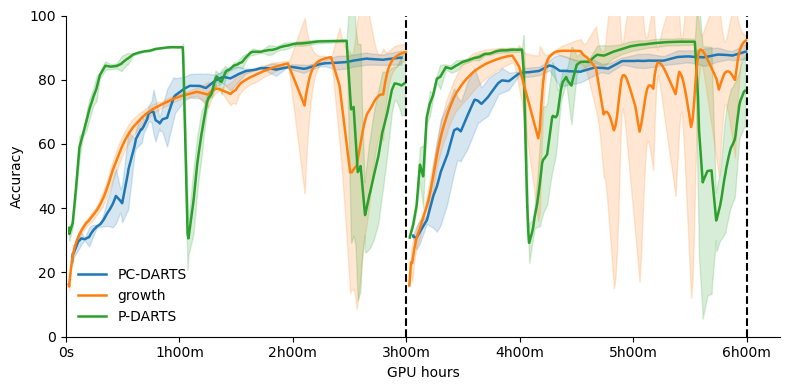

In [ ]:
fig, ax = plot_metrics_with_ci({k:v for k,v in groups.items() if "growth-continue" != k}, metric_keys=["training/val accuracy", "search/val accuracy"], colors=colors)

/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


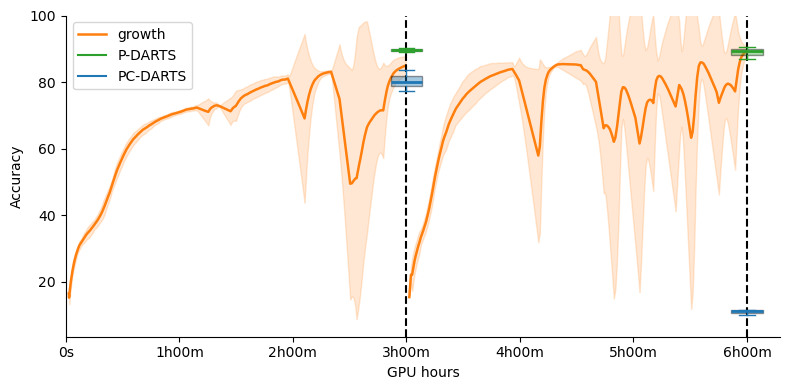

In [ ]:
fig, ax = plot_metrics_with_ci({k:v for k,v in groups.items() if "growth-continue" != k}, metric_keys=["training/test accuracy"], colors=colors)
add_box(ax, eval_groups)

## Ablation

In [224]:
strategies = ["restricted", "hsic", "greedy", "random"]
multnist_runs = load_runs("Strategies-MultNIST-scalar", entity=ENTITY,
                        filters={
                              "config.growth.neuron_selection_threshold.value": 0.00028,
                              "config.training.es_abs_delta.value": 0.00122,
                              "group": {"$in" : strategies},
                              "config.model.init_hidden_channels.value": 64,
                        }
)
groups = group_df(multnist_runs, by="group")

Found 20 runs in 'Strategies-MultNIST-scalar'


In [231]:
groups = dict(sorted(groups.items(), key=lambda item: strategies.index(item[0])))
groups

{'restricted': [<Run stella_douka-personal/Strategies-MultNIST-scalar/s17zoagr (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/8y7tarnb (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/b5zwwwfv (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/x005tkah (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/iyc16a88 (finished)>],
 'hsic': [<Run stella_douka-personal/Strategies-MultNIST-scalar/31vk563a (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/h7qpxzxb (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/nyclb1ot (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/rfjrvpvh (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/xpyhx5kk (finished)>],
 'greedy': [<Run stella_douka-personal/Strategies-MultNIST-scalar/6hpv9932 (finished)>,
  <Run stella_douka-personal/Strategies-MultNIST-scalar/im3axdu0 (finished)>,
  <Run stella_douka-personal/S

In [232]:
colors = {}
idx = 0
for group in list(groups.keys()):
    group = str(group).split("-continue")[0]
    if group not in colors:
        colors[group] = wong_colors[idx]
        idx += 1
colors

{'restricted': '#0072B2',
 'hsic': '#E69F00',
 'greedy': '#009E73',
 'random': '#CC79A7'}

/tmp/ipykernel_8713/1084433896.py:6: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.35)
/tmp/ipykernel_8713/1084433896.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


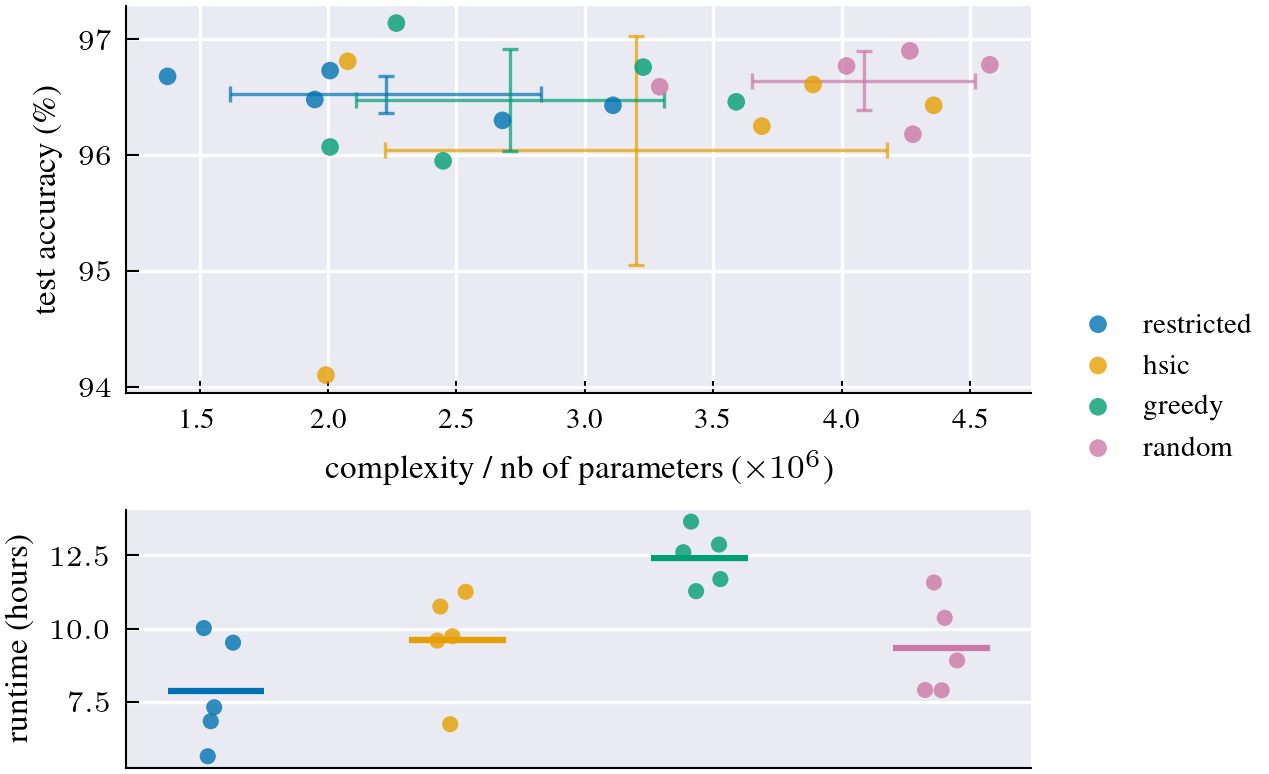

In [230]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, #figsize=(3.5, 4.5),
    gridspec_kw={"height_ratios": [3, 2]},
    sharex=False,
)
fig.subplots_adjust(hspace=0.35)
for i, (exp_name, seeds) in enumerate(groups.items()):
    accs   = [s.summary["training/test accuracy"] * 100 for s in seeds]
    params = [s.summary["complexity/nb of parameters"] for s in seeds]
    runtimes = [s.summary["_runtime"]/3600 for s in seeds]
    
    ax1.scatter(params, accs,
               color=colors[exp_name], s=18, zorder=5,
               label=exp_name, alpha=0.8, linewidths=0.4, edgecolors="none")
    
    # optionally draw a cross showing marginal spread
    ax1.errorbar(np.mean(params), np.mean(accs),
                xerr=np.std(params), yerr=np.std(accs),
                fmt="none", color=colors[exp_name],
                linewidth=0.8, capsize=2, capthick=0.8, alpha=0.7)
    
    # jitter x slightly so points don't overlap
    x_jitter = np.random.uniform(-0.1, 0.1, size=len(runtimes))
    ax2.scatter(np.full(len(runtimes), i) + x_jitter, runtimes,
                  color=colors[exp_name], s=15, zorder=5, alpha=0.8, edgecolors="none")
    
    # mean line
    ax2.hlines(np.mean(runtimes), i - 0.2, i + 0.2,
                 color=colors[exp_name], linewidth=1.5)

fig.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
ax1.set_ylabel("test accuracy (\%)")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax1.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax2.set_ylabel("runtime (hours)")
ax2.set_xticks([])
# ax2.set_xticks([0, 1, 2, 3])
# ax2.set_xticklabels(strategies)
fig.show()
fig.savefig("../temp/plots/ablation.png")

## Growth

In [22]:
nas_runs = load_runs("NAS", entity=ENTITY,
                filters={
                    "config.no_augment": {"$nin": [True]}
                }
            )
nas_groups = group_df(nas_runs, by="dataset")
print(nas_groups.keys())
for key, values in nas_groups.items():
    nas_groups[key] = group_df(values, by="group")
nas_groups

Found 74 runs in 'NAS'
dict_keys(['multnist', 'gutenberg', 'chesseract', 'geoclassing', 'cifartile', 'None'])


{'multnist': {'ENAS': [<Run stella_douka-personal/NAS/5x1yfg4k (finished)>,
   <Run stella_douka-personal/NAS/3gkic2lg (finished)>,
   <Run stella_douka-personal/NAS/5ukltvxj (finished)>],
  'PC-DARTS': [<Run stella_douka-personal/NAS/7x5ag47n (finished)>,
   <Run stella_douka-personal/NAS/z173zhx3 (finished)>,
   <Run stella_douka-personal/NAS/eiyvwgxe (finished)>],
  'DARTS': [<Run stella_douka-personal/NAS/wn8xc873 (finished)>,
   <Run stella_douka-personal/NAS/e3m5eor1 (finished)>,
   <Run stella_douka-personal/NAS/d0i5vbiz (finished)>],
  'P-DARTS': [<Run stella_douka-personal/NAS/trmapf4k (finished)>,
   <Run stella_douka-personal/NAS/yccod5hc (finished)>,
   <Run stella_douka-personal/NAS/b25cf2ue (finished)>]},
 'gutenberg': {'ENAS': [<Run stella_douka-personal/NAS/7evsy4tz (finished)>,
   <Run stella_douka-personal/NAS/gnavz1yv (finished)>,
   <Run stella_douka-personal/NAS/o312wo4w (finished)>],
  'DARTS': [<Run stella_douka-personal/NAS/vi7x8hyy (finished)>,
   <Run stella_d

In [23]:
def read_wandb_zip(zip_path: str) -> dict[str, dict[str, [list[pd.DataFrame]]]]:
    """
    Read a zip of wandb CSV history files, grouped by run group.
    
    Each CSV filename is expected to follow wandb's export convention:
        <project>_<group>_<run_name>_history.csv  (or similar)
    
    Args:
        zip_path: Path to the zip file.

    Returns:
        A dict mapping group name -> list of DataFrames (one per run).
    """
    grouped = {}

    with zipfile.ZipFile(zip_path, "r") as zf:
        csv_files = [f for f in zf.namelist() if f.endswith(".csv")]

        for fname in csv_files:
            with zf.open(fname) as f:
                df = pd.read_csv(f, index_col=0)

            # --- parse group from filename ---
            # Adapt this logic to your actual filename convention
            stem = fname.split("/")[-1].replace(".csv", "")
            parts = stem.split("-")
            dataset = parts[1] if len(parts) > 1 else "none"
            group = parts[0] if len(parts) > 1 else "none"
            if group == "pdarts":
                group = "P-DARTS"
            if group == "pcdarts":
                group = "PC-DARTS"

            if dataset not in grouped:
                grouped[dataset] = defaultdict(list)

            grouped[dataset][group].append(df)

    for k, v in grouped.items():
        grouped[k] = dict(v)
    return dict(grouped)


extra_runs = read_wandb_zip("/home/sdouka/Downloads/pdarts_results.zip")

for dataset, v in extra_runs.items():
    for group, dfs in v.items():
        print(f"Dataset {dataset} - Group '{group}': {len(dfs)} run(s), columns: {dfs[0].columns.tolist()}")

Dataset chesseract - Group 'P-DARTS': 6 run(s), columns: ['training/train loss', '_timestamp', 'training/test accuracy', 'training/train accuracy', 'training/nb of parameters', '_step', 'epoch', '_runtime', 'training/test loss']
Dataset gutenberg - Group 'P-DARTS': 6 run(s), columns: ['search/test accuracy', 'search/test loss', 'search/train accuracy', 'search/train loss', 'search/val accuracy', 'search/val loss']
Dataset multnist - Group 'P-DARTS': 6 run(s), columns: ['training/train accuracy', '_step', '_timestamp', 'training/train loss', 'training/test accuracy', 'training/nb of parameters', 'epoch', '_runtime', 'training/test loss']


In [24]:
# extra_runs['multnist']['P-DARTS'][0]

In [25]:
for dataset, v in extra_runs.items():
    for group, dfs in v.items():
        nas_groups[dataset][group] = dfs

In [26]:
# extra_runs = read_wandb_zip("/home/sdouka/Downloads/pdarts_gutenberg.zip")

# for dataset, v in extra_runs.items():
#     for group, dfs in v.items():
#         print(f"Dataset {dataset} - Group '{group}': {len(dfs)} run(s), columns: {dfs[0].columns.tolist()}")

In [27]:
# for dataset, v in extra_runs.items():
#     for group, dfs in v.items():
#         nas_groups[dataset][group] = dfs

In [28]:
extra_runs = read_wandb_zip("/home/sdouka/Downloads/pcdarts_runtime.zip")

for dataset, v in extra_runs.items():
    for group, dfs in v.items():
        print(f"Dataset {dataset} - Group '{group}': {len(dfs)} run(s), columns: {dfs[0].columns.tolist()}")

Dataset chesseract - Group 'PC-DARTS': 6 run(s), columns: ['search/test accuracy', 'search/test loss', 'search/train accuracy', 'search/train loss', 'search/val accuracy', 'search/val loss', '_runtime']
Dataset gutenberg - Group 'PC-DARTS': 6 run(s), columns: ['search/test accuracy', 'search/test loss', 'search/train accuracy', 'search/train loss', 'search/val accuracy', 'search/val loss', '_runtime']
Dataset gutenberg - Group 'P-DARTS': 6 run(s), columns: ['search/test accuracy', 'search/test loss', 'search/train accuracy', 'search/train loss', 'search/val accuracy', 'search/val loss', '_runtime']
Dataset multnist - Group 'PC-DARTS': 6 run(s), columns: ['search/test accuracy', 'search/test loss', 'search/train accuracy', 'search/train loss', 'search/val accuracy', 'search/val loss', '_runtime']


In [29]:
for dataset, v in extra_runs.items():
    for group, dfs in v.items():
        nas_groups[dataset][group] = dfs

In [98]:
multnist_runs = load_runs("Strategies-MultNIST-scalar", entity=ENTITY,
                        filters={
                              "config.growth.neuron_selection_threshold.value": 0.00028,
                              "config.training.es_abs_delta.value": 0.00122,
                              "group": {"$in" : ["restricted", "scratch-restricted"]},
                              "config.model.init_hidden_channels.value": 64,
                        }
)
groups = group_df(multnist_runs, by="group")

Found 10 runs in 'Strategies-MultNIST-scalar'


In [22]:
maximums = []
for run in groups["restricted"]:
    hist = run.history(keys=["epoch", "training/test accuracy"])
    total_epochs = hist["epoch"].max()
    max_accuracy = hist.loc[hist["training/test accuracy"].idxmax()]
    maximums.append(max_accuracy["training/test accuracy"]*100)
    print(run.name, run.id)
    print(total_epochs)
    print(max_accuracy)
    print("In the final epochs?", total_epochs - max_accuracy['epoch'] < 200)
    print()
np.mean(maximums), np.std(maximums)

rural-wildflower-317 s17zoagr
418
_step                     5898.0000
epoch                      362.0000
training/test accuracy       0.9654
Name: 362, dtype: float64
In the final epochs? True

royal-bee-318 8y7tarnb
414
_step                     5828.0000
epoch                      406.0000
training/test accuracy       0.9668
Name: 406, dtype: float64
In the final epochs? True

legendary-violet-319 b5zwwwfv
409
_step                     6201.0000
epoch                      352.0000
training/test accuracy       0.9697
Name: 352, dtype: float64
In the final epochs? True

splendid-frost-332 x005tkah
398
_step                     6177.0000
epoch                      350.0000
training/test accuracy       0.9664
Name: 350, dtype: float64
In the final epochs? True

giddy-cherry-333 iyc16a88
431
_step                     6095.0000
epoch                      391.0000
training/test accuracy       0.9662
Name: 391, dtype: float64
In the final epochs? True



(96.68999910354614, 0.14724079543683635)

In [85]:
colors = {}
idx = 0
for group in list(groups.keys())+list(nas_groups['multnist'].keys()):
    group = str(group).split("-continue")[0]
    if group not in colors:
        colors[group] = wong_colors[idx]
        idx += 1
colors['None'] = "#009E73"
colors

{'restricted': '#0072B2',
 'scratch-restricted': '#E69F00',
 'ENAS': '#009E73',
 'PC-DARTS': '#CC79A7',
 'DARTS': '#56B4E9',
 'P-DARTS': '#D55E00',
 'None': '#009E73'}

In [72]:
x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
width = 0.05 * x_range
width

294536.22000000003

In [124]:
# fig, ax = plot_metrics_with_ci_step(groups, metric_keys=["training/train accuracy", "training/test accuracy"], title="MultNIST")
fig, ax = plot_metrics_with_ci_step({k:v for k,v in groups.items() if "scratch" not in k},                            
        metric_keys=["training/test accuracy"],
        step="complexity/nb of parameters", title="MultNIST", step_key="epoch",
        smooth_window=4,
)
myHandle, extra_labels = add_box(ax, nas_groups["multnist"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(30, 100.5)
ax.set_xlim(left=0, right=None)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

# ax.annotate("ENAS\n(high variance)", xy=(5.2e6, 36),
#             xytext=(4.5e6, 32), fontsize=6,
#             arrowprops=dict(arrowstyle="->", lw=0.8),
#             color=colors["ENAS"])

fig.show()
fig.savefig("../temp/plots/multnist.png")

: 

ENAS
Parameters: [5377390, 5377390, 5377390]
Mean parameters: 5377390.0
Values: [36.230000000000004, 79.28, 79.04] 

PC-DARTS
Parameters: [2911294, 3488014, 3937726]
Mean parameters: 3445678.0
Values: [96.67, 97.11, 97.66] 

DARTS
Parameters: [3595728, 3916056, 3488376]
Mean parameters: 3666720.0
Values: [97.80000308036804, 97.73000348091124, 97.88000361442566] 

P-DARTS
Parameters: [3474838.0, 3480670.0, 3727126.0]
Mean parameters: 3560878.0
Values: [97.09, 96.86, 97.92999999999999] 

scratch-restricted
Parameters: [1375662, 2008517, 1948817, 2679822, 3109889]
Mean parameters: 2224541.4
Values: [92.86999702453612, 93.62000226974489, 93.91999840736388, 93.83999705314636, 93.80999803543092] 



/tmp/ipykernel_7813/1433136828.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


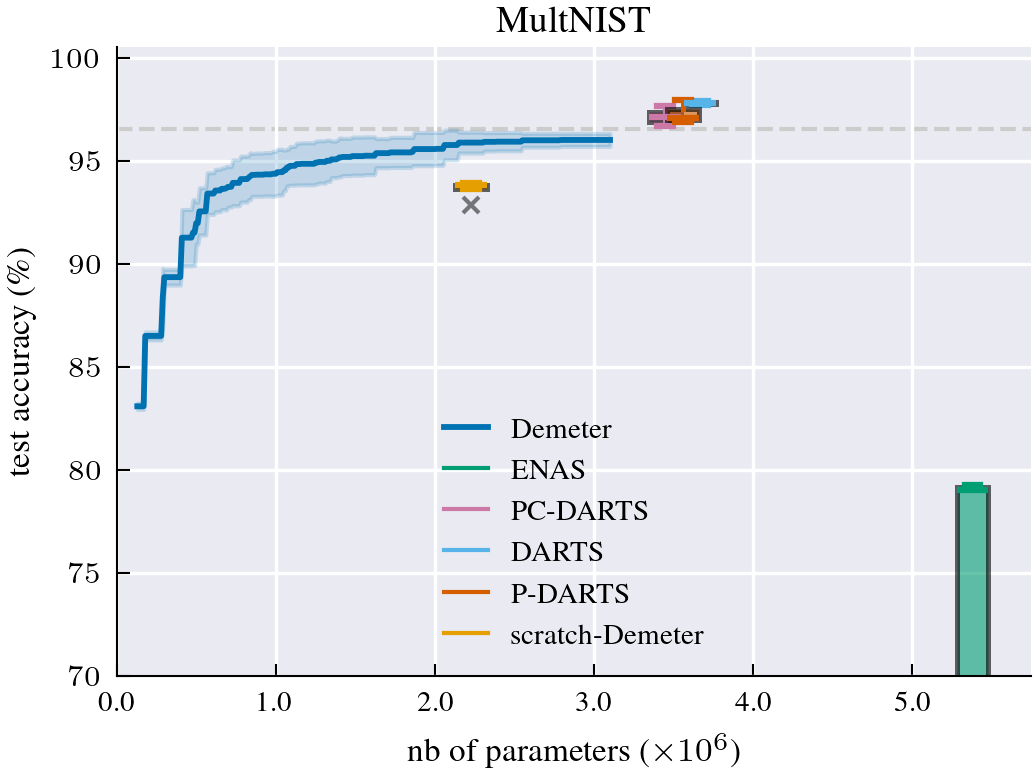

In [75]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k},
        metric_keys=["training/test accuracy"],
        step="complexity/nb of parameters", title="MultNIST", step_key="epoch",
        # smooth_window=4,
        bin_size=10_000,
        use_max=True,
        use_cummax=True,
)
myHandle, extra_labels = add_box(ax, nas_groups["multnist"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(70, 100.5)
ax.set_xlim(left=0, right=None)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/multnist_bin.png")

/tmp/ipykernel_50930/3707101609.py:7: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.08)


ENAS
Parameters: [5377390, 5377390, 5377390]
Mean parameters: 5377390.0
Values: [36.230000000000004, 79.28, 79.04] 

PC-DARTS
Parameters: [3703150, 3747430, 3703798]
Mean parameters: 3718126.0
Values: [97.7, 98.27, 97.39] 

DARTS
Parameters: [3595728, 3916056, 3488376]
Mean parameters: 3666720.0
Values: [97.80000308036804, 97.73000348091124, 97.88000361442566] 

P-DARTS
Parameters: [4211182, 3448702, 3473326]
Mean parameters: 3711070.0
Values: [97.8, 96.95, 97.83] 

scratch-restricted
Parameters: [1375662, 2008517, 1948817, 2679822, 3109889]
Mean parameters: 2224541.4
Values: [92.86999702453612, 93.62000226974489, 93.91999840736388, 93.83999705314636, 93.80999803543092] 



/tmp/ipykernel_50930/3707101609.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


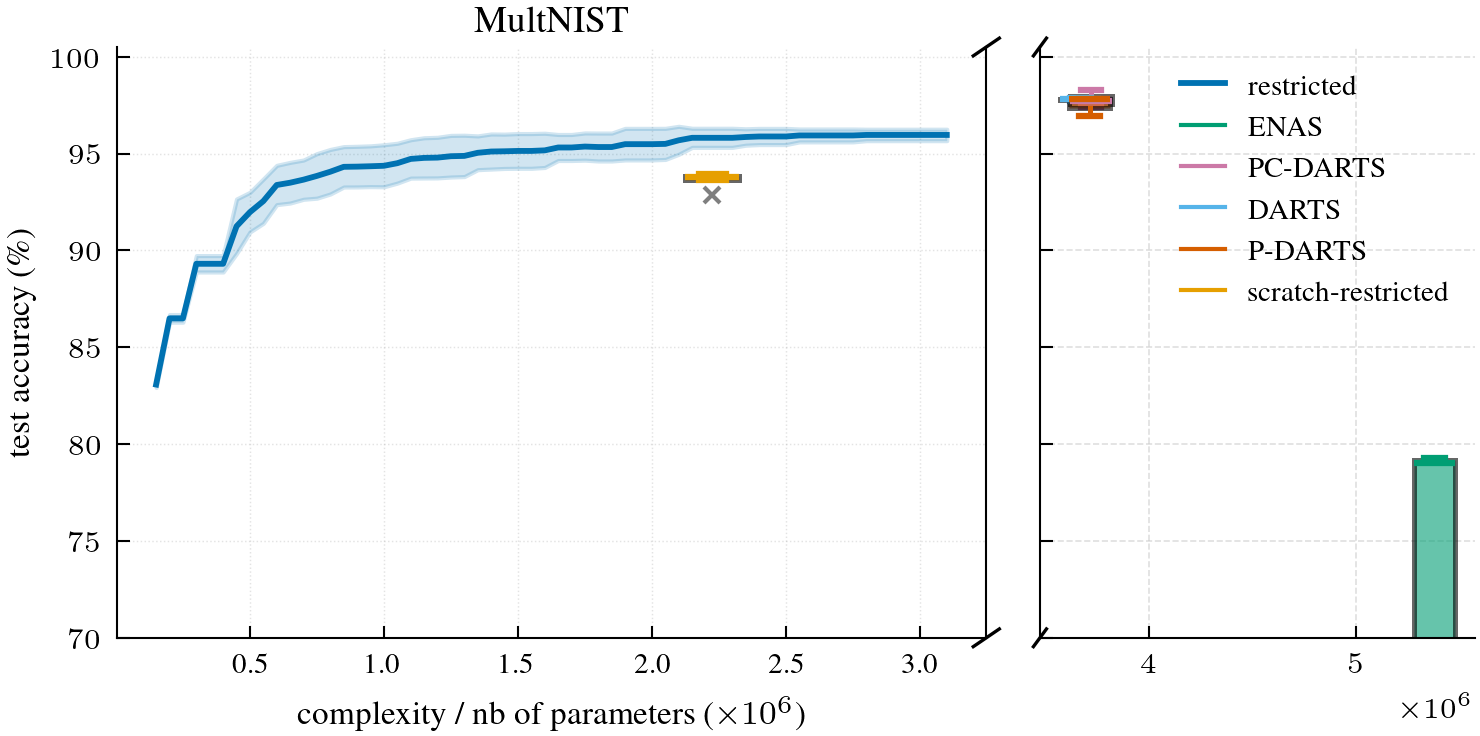

In [32]:
fig, (ax_left, ax_right) = plt.subplots(
        1, 2,
        figsize=(5, 2.5),  # full double-column width, less tall
        gridspec_kw={"width_ratios": [2, 1]},  # left panel wider
        sharey=True,
)
fig.subplots_adjust(wspace=0.08)
# ax_left.set_xlim(right=2.2e6)
# ax_right.set_xlim(left=3.5e6)

# broken axis visual indicator — diagonal ticks on the gap edges
for ax, spine_side in [(ax_left, "right"), (ax_right, "left")]:
    ax.spines[spine_side].set_visible(True)
    d = 0.015
    kwargs = dict(transform=ax.transAxes, color="k", clip_on=False, linewidth=0.8)
    if spine_side == "right":
        ax.plot((1-d, 1+d), (-d, +d), **kwargs)
        ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
    else:
        ax.plot((-d, +d), (-d, +d), **kwargs)
        ax.plot((-d, +d), (1-d, 1+d), **kwargs)


fig, ax_left = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k},
        ax=ax_left,
        metric_keys=["training/test accuracy"],
        step="complexity/nb of parameters", title="MultNIST", step_key="epoch",
        # smooth_window=4,
        bin_size=50_000,
)
myHandle, extra_labels = add_box(ax_right, nas_groups["multnist"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax_left, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax_left, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax_left.set_ylim(70, 100.5)
# ax_left.set_xlim(left=0, right=None)
ax_left.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax_left.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax_left.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/multnist_bin_sep.png")

/tmp/ipykernel_7813/353795442.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


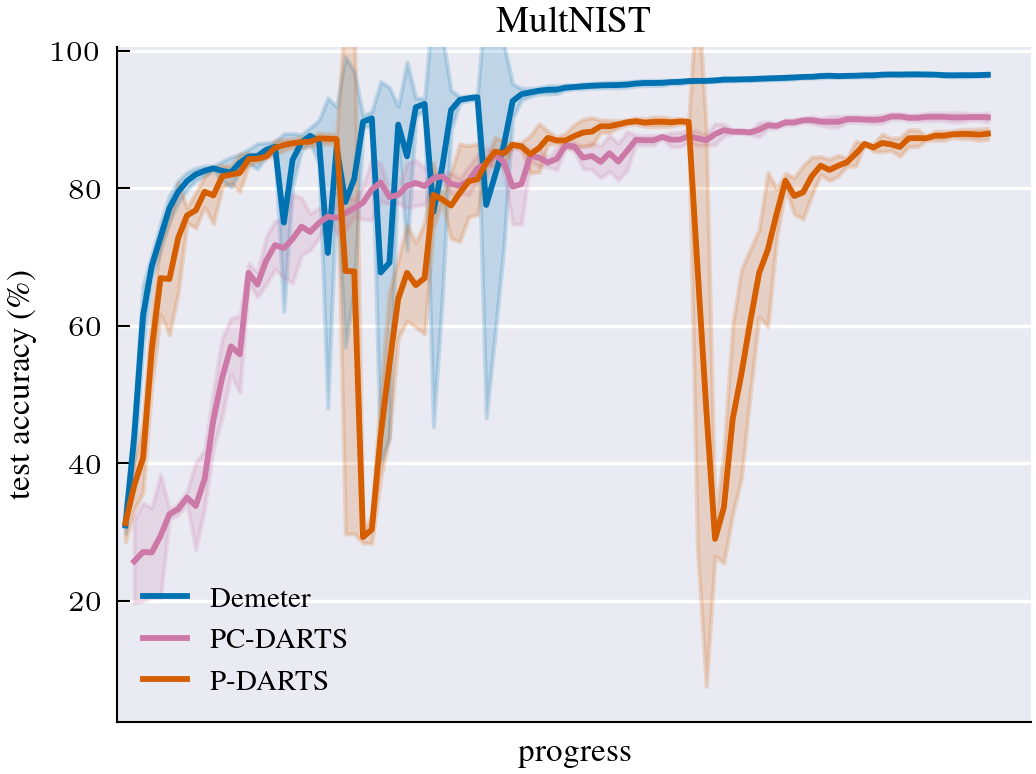

In [76]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k},
        metric_keys=["training/test accuracy"],
        step="_runtime", title="MultNIST", step_key="epoch",
        # smooth_window=4,
        bin_size=100,
        use_max=True,
        normalize_x=True,
        guides=False,
)
fig, ax = plot_metrics_with_ci_fin(nas_groups["multnist"],
        ax=ax,
        metric_keys=["search/test accuracy"],
        step="_runtime", step_key="search epoch",
        bin_size=100,
        use_max=True,
        normalize_x=True,
        guides=False,
)
legend(ax, frameon=False)
ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)
# ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_runtime))
ax.set_xlabel("progress")
ax.set_ylabel("test accuracy (\%)")
ax.set_xticks([])

fig.show()
fig.savefig("../temp/plots/multnist_1shot.png")

In [60]:
cifartile_runs = load_runs("Strategies-CifarTile-scalar", entity=ENTITY,
                        filters={
                              "config.growth.neuron_selection_threshold.value": 0.00028,
                              "config.training.es_abs_delta.value": 0.00122,
                              "group": {"$in" : ["restricted", "scratch-restricted"]},
                              "config.model.init_hidden_channels.value": 64,
                        }
)
groups = group_df(cifartile_runs, by="group")

Found 6 runs in 'Strategies-CifarTile-scalar'


In [38]:
maximums = []
for run in groups["restricted"]:
    hist = run.history(keys=["epoch", "training/test accuracy"])
    total_epochs = hist["epoch"].max()
    max_accuracy = hist.loc[hist["training/test accuracy"].idxmax()]
    maximums.append(max_accuracy["training/test accuracy"]*100)
    print(run.name)
    print("Total epochs", total_epochs)
    print(max_accuracy)
    print("In the final epochs?", total_epochs - max_accuracy['epoch'] < 200)
    print()
np.mean(maximums), np.std(maximums)

radiant-breeze-9
Total epochs 289
_step                     988.0000
epoch                     120.0000
training/test accuracy      0.5303
Name: 120, dtype: float64
In the final epochs? True

solar-resonance-11
Total epochs 345
_step                     1090.0000
epoch                      137.0000
training/test accuracy       0.5477
Name: 137, dtype: float64
In the final epochs? False

upbeat-vortex-10
Total epochs 328
_step                     1727.0000
epoch                      218.0000
training/test accuracy       0.6007
Name: 218, dtype: float64
In the final epochs? True



(55.95666766166687, 2.994053787764025)

ENAS
Parameters: [5376904, 5376904, 5376904]
Mean parameters: 5376904.0
Values: [24.73, 24.73, 24.43] 

P-DARTS
Parameters: [4035352, 3680896, 3335944]
Mean parameters: 3684064.0
Values: [24.43, 24.82, 24.82] 

DARTS
Parameters: [4169772, 3920940, 4239540]
Mean parameters: 4110084.0
Values: [88.16000183105469, 85.51000190734864, 86.31000200271608] 

PC-DARTS
Parameters: [2743240, 3378928, 1366672]
Mean parameters: 2496280.0
Values: [57.13, 57.38999999999999, 51.93] 

scratch-restricted
Parameters: [654663, 606566, 1109670]
Mean parameters: 790299.6666666666
Values: [48.71000051498413, 47.09999859333038, 48.8400012254715] 



/tmp/ipykernel_147109/787911899.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


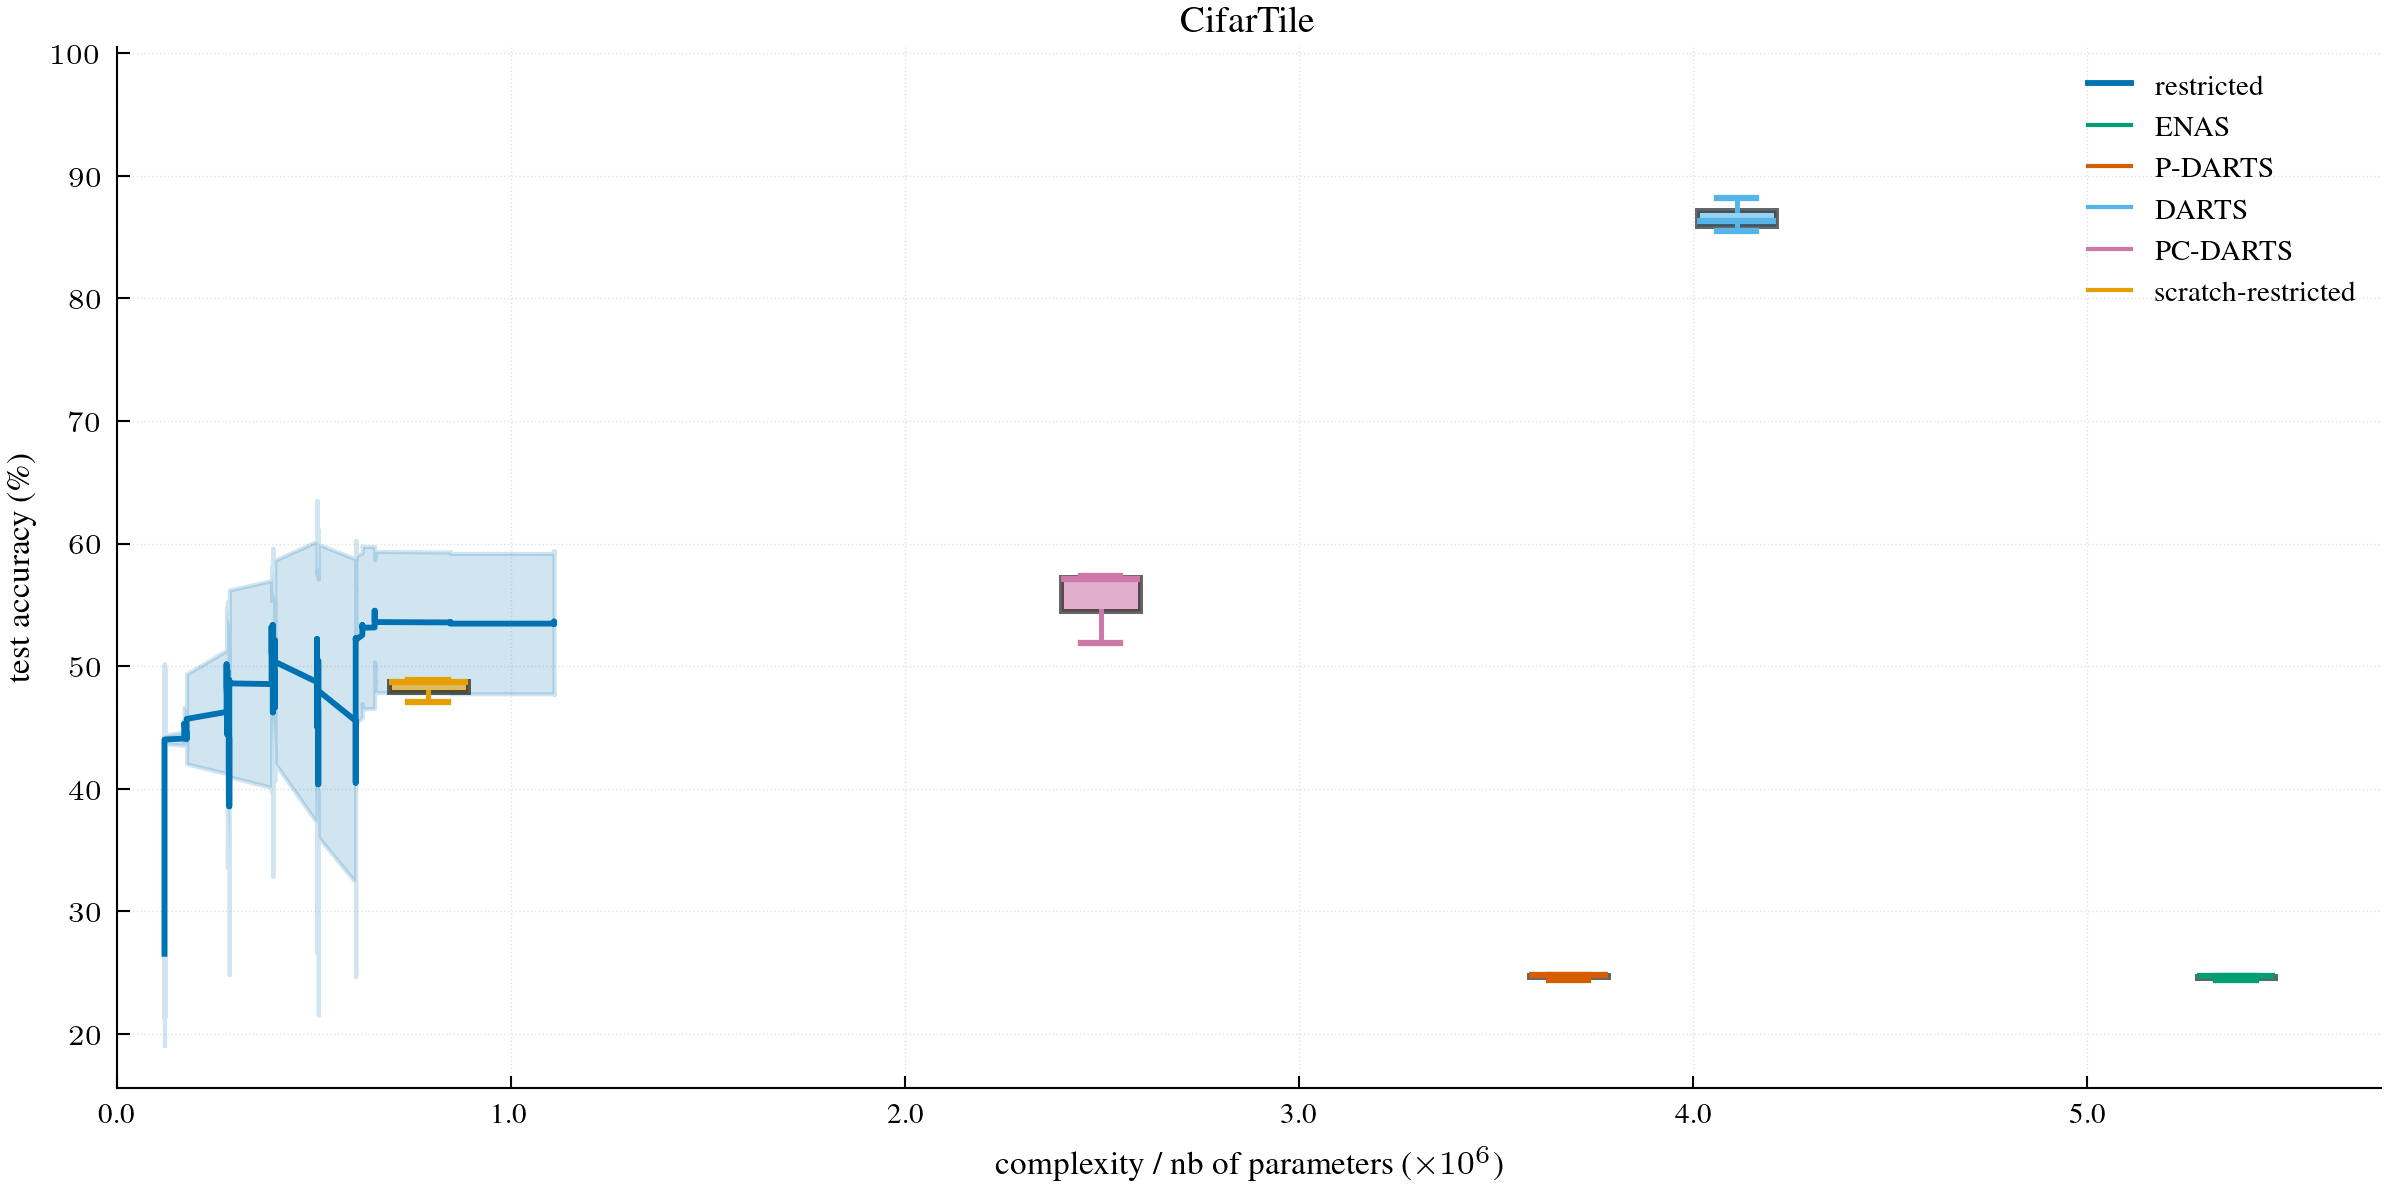

In [110]:
fig, ax = plot_metrics_with_ci_step({k:v for k,v in groups.items() if "scratch" not in k}, 
        metric_keys=["training/test accuracy"], 
        title="CifarTile",
        step="complexity/nb of parameters", step_key="epoch",
        smooth_window=4,
)
myHandle, extra_labels = add_box(ax, nas_groups["cifartile"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/cifartile.png")

ENAS
Parameters: [5376904, 5376904, 5376904]
Mean parameters: 5376904.0
Values: [24.73, 24.73, 24.43] 

P-DARTS
Parameters: [4035352, 3680896, 3335944]
Mean parameters: 3684064.0
Values: [24.43, 24.82, 24.82] 

DARTS
Parameters: [4169772, 3920940, 4239540]
Mean parameters: 4110084.0
Values: [88.16000183105469, 85.51000190734864, 86.31000200271608] 

PC-DARTS
Parameters: [2743240, 3378928, 1366672]
Mean parameters: 2496280.0
Values: [57.13, 57.38999999999999, 51.93] 

scratch-restricted
Parameters: [654663, 606566, 1109670]
Mean parameters: 790299.6666666666
Values: [48.71000051498413, 47.09999859333038, 48.8400012254715] 



/tmp/ipykernel_7813/3571548651.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


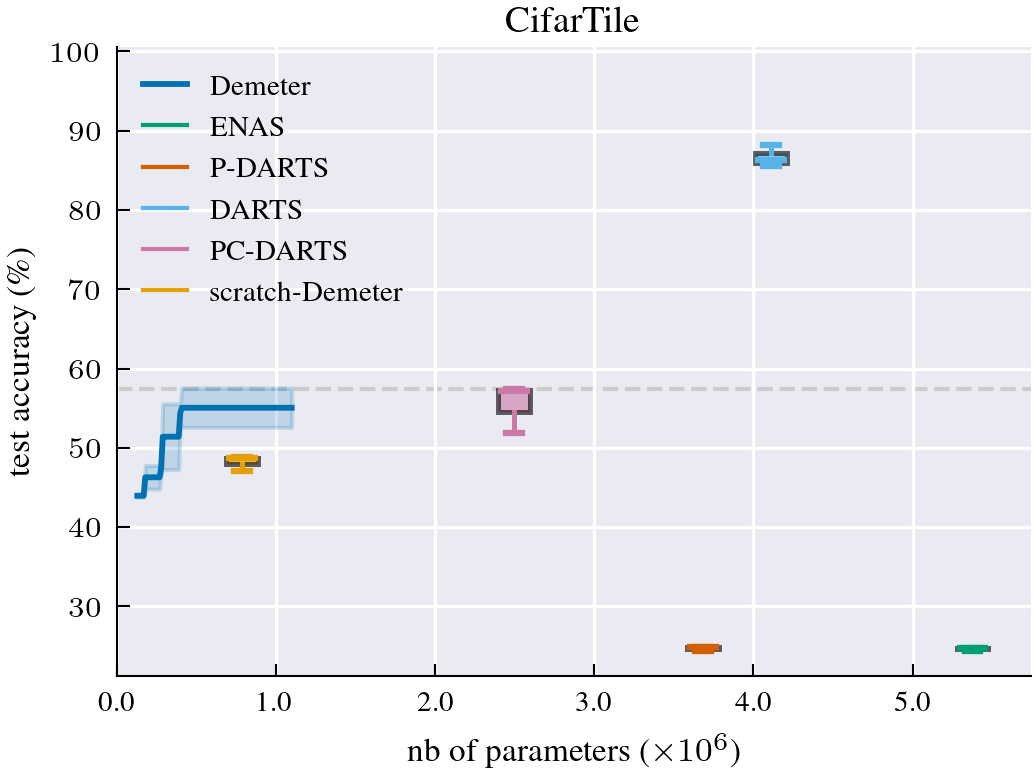

In [62]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k}, 
        metric_keys=["training/test accuracy"], 
        title="CifarTile",
        step="complexity/nb of parameters", step_key="epoch",
        # smooth_window=4,
        bin_size=10_000,
        use_max=True,
        use_cummax=True,
)
myHandle, extra_labels = add_box(ax, nas_groups["cifartile"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/cifartile_bin.png")

In [63]:
gutenberg_runs = load_runs("Strategies-Gutenberg-scalar", entity=ENTITY,
                        filters={
                              "config.growth.neuron_selection_threshold.value": 0.00028,
                              "config.training.es_abs_delta.value": 0.00122,
                              "config.growth.steps.value": 60,
                              "group": {"$in" : ["restricted", "scratch-restricted"]},
                              "config.model.init_hidden_channels.value": 64,
                        }
)
groups = group_df(gutenberg_runs, by="group")

Found 6 runs in 'Strategies-Gutenberg-scalar'


In [42]:
maximums = []
for run in groups["restricted"]:
    hist = run.history(keys=["epoch", "training/test accuracy"])
    total_epochs = hist["epoch"].max()
    max_accuracy = hist.loc[hist["training/test accuracy"].idxmax()]
    maximums.append(max_accuracy["training/test accuracy"]*100)
    print(run.name)
    print(total_epochs)
    print(max_accuracy)
    print("In the final epochs?", total_epochs - max_accuracy['epoch'] < 200)
    print()
np.mean(maximums), np.std(maximums)

polar-firefly-17
297
_step                     2702.000000
epoch                      122.000000
training/test accuracy       0.427667
Name: 122, dtype: float64
In the final epochs? True

dark-violet-16
296
_step                     1864.0000
epoch                      118.0000
training/test accuracy       0.4105
Name: 118, dtype: float64
In the final epochs? True

drawn-pine-18
304
_step                     4510.000000
epoch                      180.000000
training/test accuracy       0.419333
Name: 180, dtype: float64
In the final epochs? True



(41.916666428248085, 0.7009256285462401)

ENAS
Parameters: [5375986, 5375986, 5375986]
Mean parameters: 5375986.0
Values: [28.633333333333333, 25.466666661580405, 20.133333338419597] 

DARTS
Parameters: [3672208, 4200976, 4017376]
Mean parameters: 3963520.0
Values: [49.083333333333336, 49.05000004768372, 51.70000006357829] 

PC-DARTS
Parameters: [1732002, 1968522, 1471290]
Mean parameters: 1723938.0
Values: [43.933333353678385, 45.33333332316081, 41.8499999593099] 

P-DARTS
Parameters: [2928426, 2855850, 2930586]
Mean parameters: 2904954.0
Values: [47.216666625976565, 46.149999959309895, 44.933333353678385] 

scratch-restricted
Parameters: [3749924, 4583848, 4089198]
Mean parameters: 4140990.0
Values: [41.866666078567505, 43.7333345413208, 43.26666593551636] 



/tmp/ipykernel_147109/4010762846.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


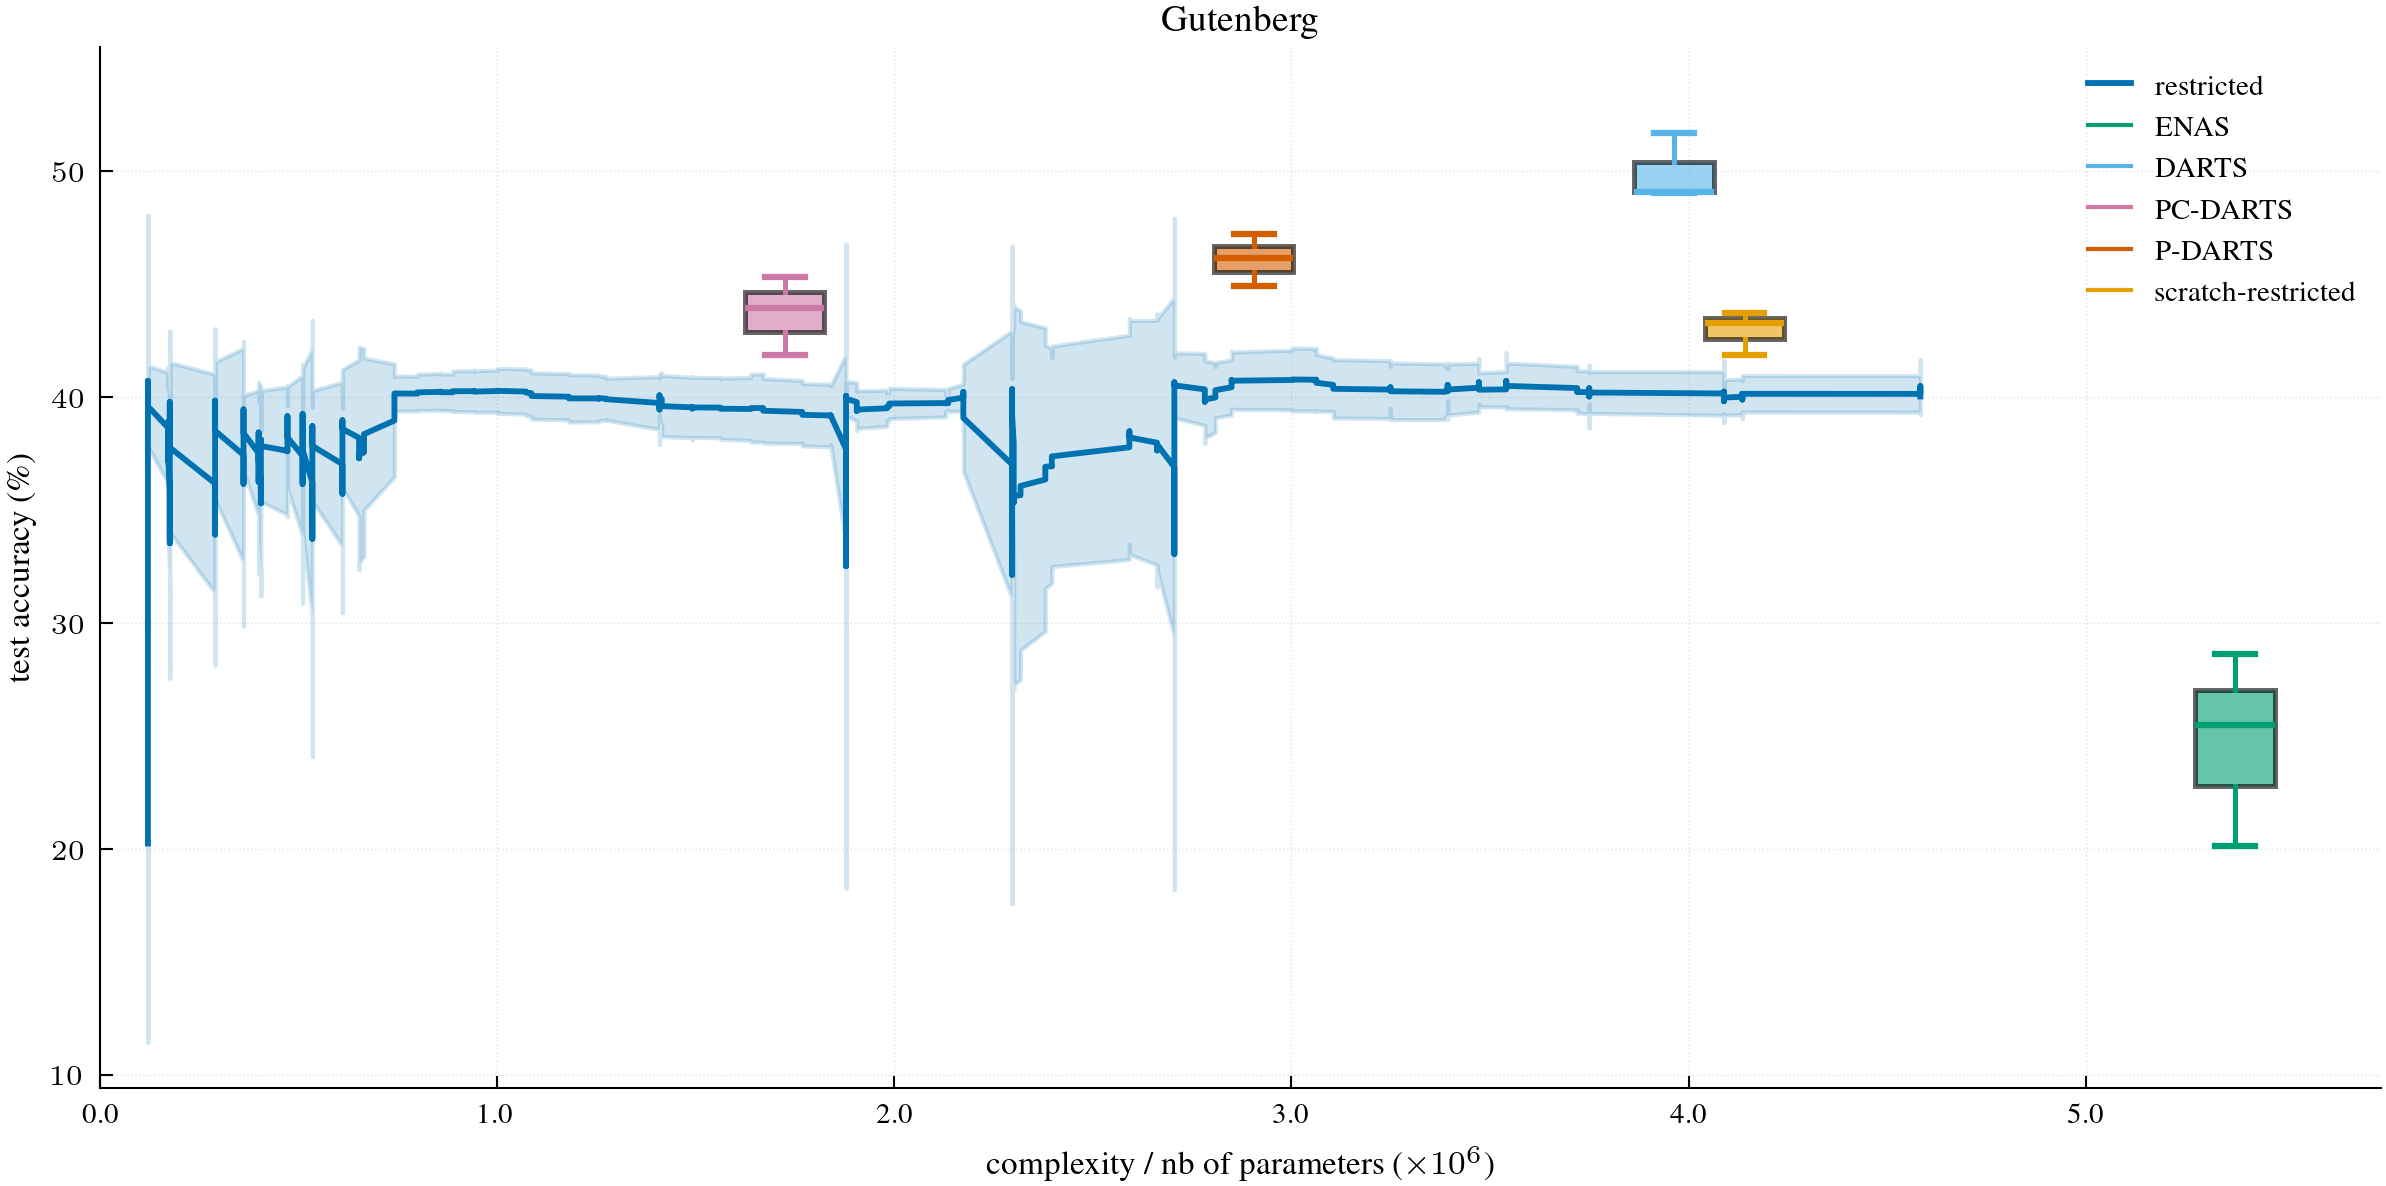

In [119]:
fig, ax = plot_metrics_with_ci_step({k:v for k,v in groups.items() if "scratch" not in k}, 
        metric_keys=["training/test accuracy"],
        title="Gutenberg",
        step="complexity/nb of parameters", step_key="epoch",
        smooth_window=4,
)
myHandle, extra_labels = add_box(ax, nas_groups["gutenberg"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(top=55.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/gutenberg.png")

ENAS
Parameters: [5375986, 5375986, 5375986]
Mean parameters: 5375986.0
Values: [28.633333333333333, 25.466666661580405, 20.133333338419597] 

DARTS
Parameters: [3672208, 4200976, 4017376]
Mean parameters: 3963520.0
Values: [49.083333333333336, 49.05000004768372, 51.70000006357829] 

PC-DARTS
Parameters: [1765914, 1525938, 1693770]
Mean parameters: 1661874.0
Values: [45.11666666666666, 42.749999959309896, 43.749999979654945] 

P-DARTS
Parameters: [2881986, 2904234, 2974650]
Mean parameters: 2920290.0
Values: [47.54999997965495, 47.24999996948242, 47.13333331298828] 

scratch-restricted
Parameters: [3749924, 4583848, 4089198]
Mean parameters: 4140990.0
Values: [41.866666078567505, 43.7333345413208, 43.26666593551636] 



/tmp/ipykernel_7813/2883640299.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


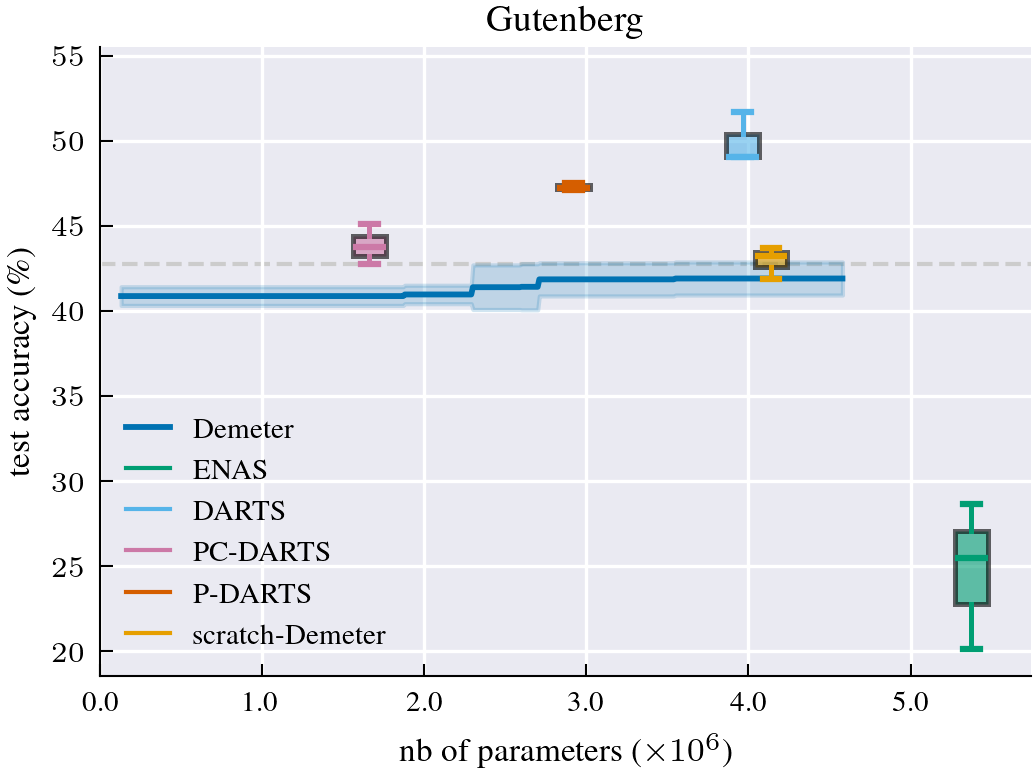

In [66]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k}, 
        metric_keys=["training/test accuracy"],
        title="Gutenberg",
        step="complexity/nb of parameters", step_key="epoch",
        # smooth_window=4,
        bin_size=10_000,
        use_max=True,
        use_cummax=True,
)
myHandle, extra_labels = add_box(ax, nas_groups["gutenberg"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(top=55.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/gutenberg_bin.png")

/tmp/ipykernel_7813/3896699459.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


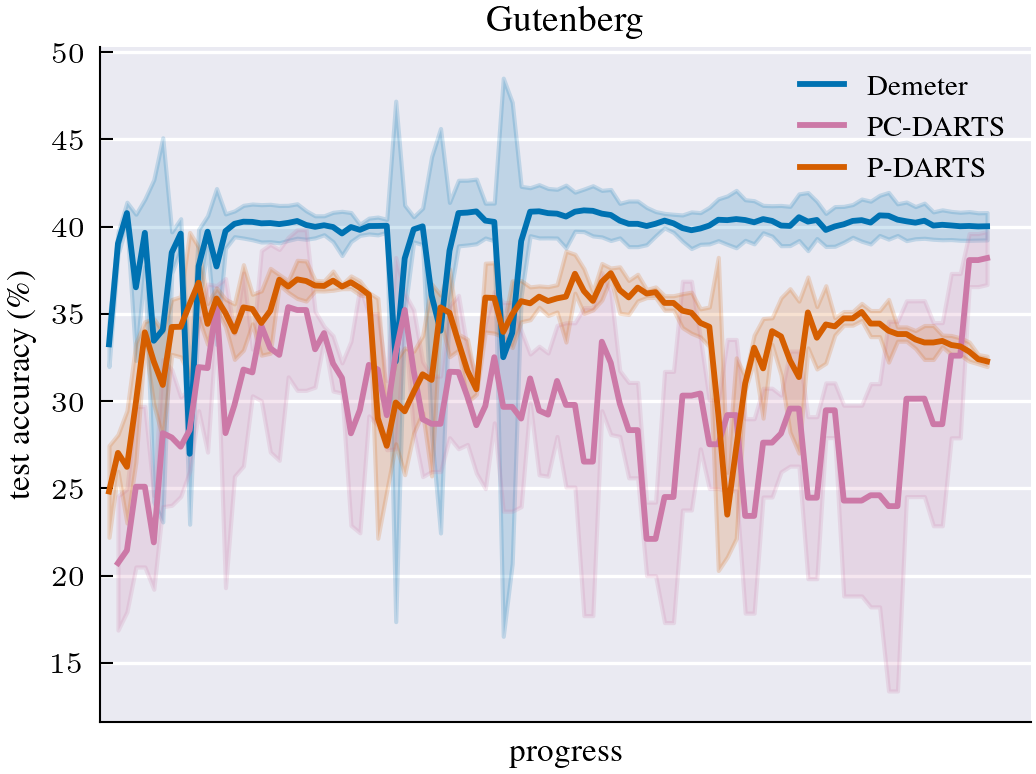

In [67]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k},
        metric_keys=["training/test accuracy"],
        step="_runtime", title="Gutenberg", step_key="epoch",
        # smooth_window=4,
        bin_size=100,
        use_max=True,
        normalize_x=True,
        guides=False,
)
fig, ax = plot_metrics_with_ci_fin(nas_groups["gutenberg"],
        ax=ax,
        metric_keys=["search/test accuracy"],
        step="_runtime", step_key="search epoch",
        bin_size=100,
        use_max=True,
        normalize_x=True,
        guides=False
)
legend(ax, frameon=False)
# ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)
ax.set_xlabel("progress")
ax.set_ylabel("test accuracy (\%)")
ax.set_xticks([])

fig.show()
fig.savefig("../temp/plots/gutenberg_1shot.png")

In [68]:
geoclassing_runs = load_runs("Strategies-Geoclassing-scalar", entity=ENTITY,
                        filters={
                              "config.growth.neuron_selection_threshold.value": 0.00028,
                              "config.training.es_abs_delta.value": 0.00122,
                              "group": {"$in" : ["restricted", "scratch-restricted"]},
                              "config.model.init_hidden_channels.value": 64,
                              "config.growth.steps.value": 60,
                        }
)
geoclassing_runs = [run for run in geoclassing_runs if run.name not in ["soft-spaceship-27", "classic-breeze-26", "fast-sea-20"]]
groups = group_df(geoclassing_runs, by="group")

Found 10 runs in 'Strategies-Geoclassing-scalar'


In [22]:
maximums = []
for run in groups["restricted"]:
    hist = run.history(keys=["epoch", "training/test accuracy"])
    total_epochs = hist["epoch"].max()
    max_accuracy = hist.loc[hist["training/test accuracy"].idxmax()]
    maximums.append(max_accuracy["training/test accuracy"]*100)
    print(run.name)
    print(total_epochs)
    print(max_accuracy)
    print("In the final epochs?", total_epochs - max_accuracy['epoch'] < 200)
    print()
np.mean(maximums), np.std(maximums)

feasible-dawn-18
593
_step                     8418.000000
epoch                      576.000000
training/test accuracy       0.952348
Name: 487, dtype: float64
In the final epochs? True

cerulean-wind-19
576
_step                     7426.000000
epoch                      567.000000
training/test accuracy       0.952577
Name: 490, dtype: float64
In the final epochs? True

northern-grass-30
671
_step                     9132.000000
epoch                      659.000000
training/test accuracy       0.957948
Name: 490, dtype: float64
In the final epochs? True



(95.42909463246663, 0.2587378521580992)

DARTS
Parameters: [4188648, 4216512, 4840320]
Mean parameters: 4415160.0
Values: [73.1344989266699, 82.92766542124647, 77.83110501929401] 

ENAS
Parameters: [5377390, 5377390, 5377390]
Mean parameters: 5377390.0
Values: [70.88332761534144, 75.47708832840281, 75.55707918223129] 

P-DARTS
Parameters: [3823246, 3371158, 3841822]
Mean parameters: 3678742.0
Values: [11.233001942199213, 11.312992800822762, 11.233001942199213] 

PC-DARTS
Parameters: [2912158, 3603142, 3158614]
Mean parameters: 3224638.0
Values: [14.101245571662188, 11.130156552991844, 29.66518112106768] 

scratch-restricted
Parameters: [2281047, 3493229, 4614518]
Mean parameters: 3462931.3333333335
Values: [93.71500611305235, 93.49788427352904, 91.32670760154724] 



/tmp/ipykernel_147109/397164270.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


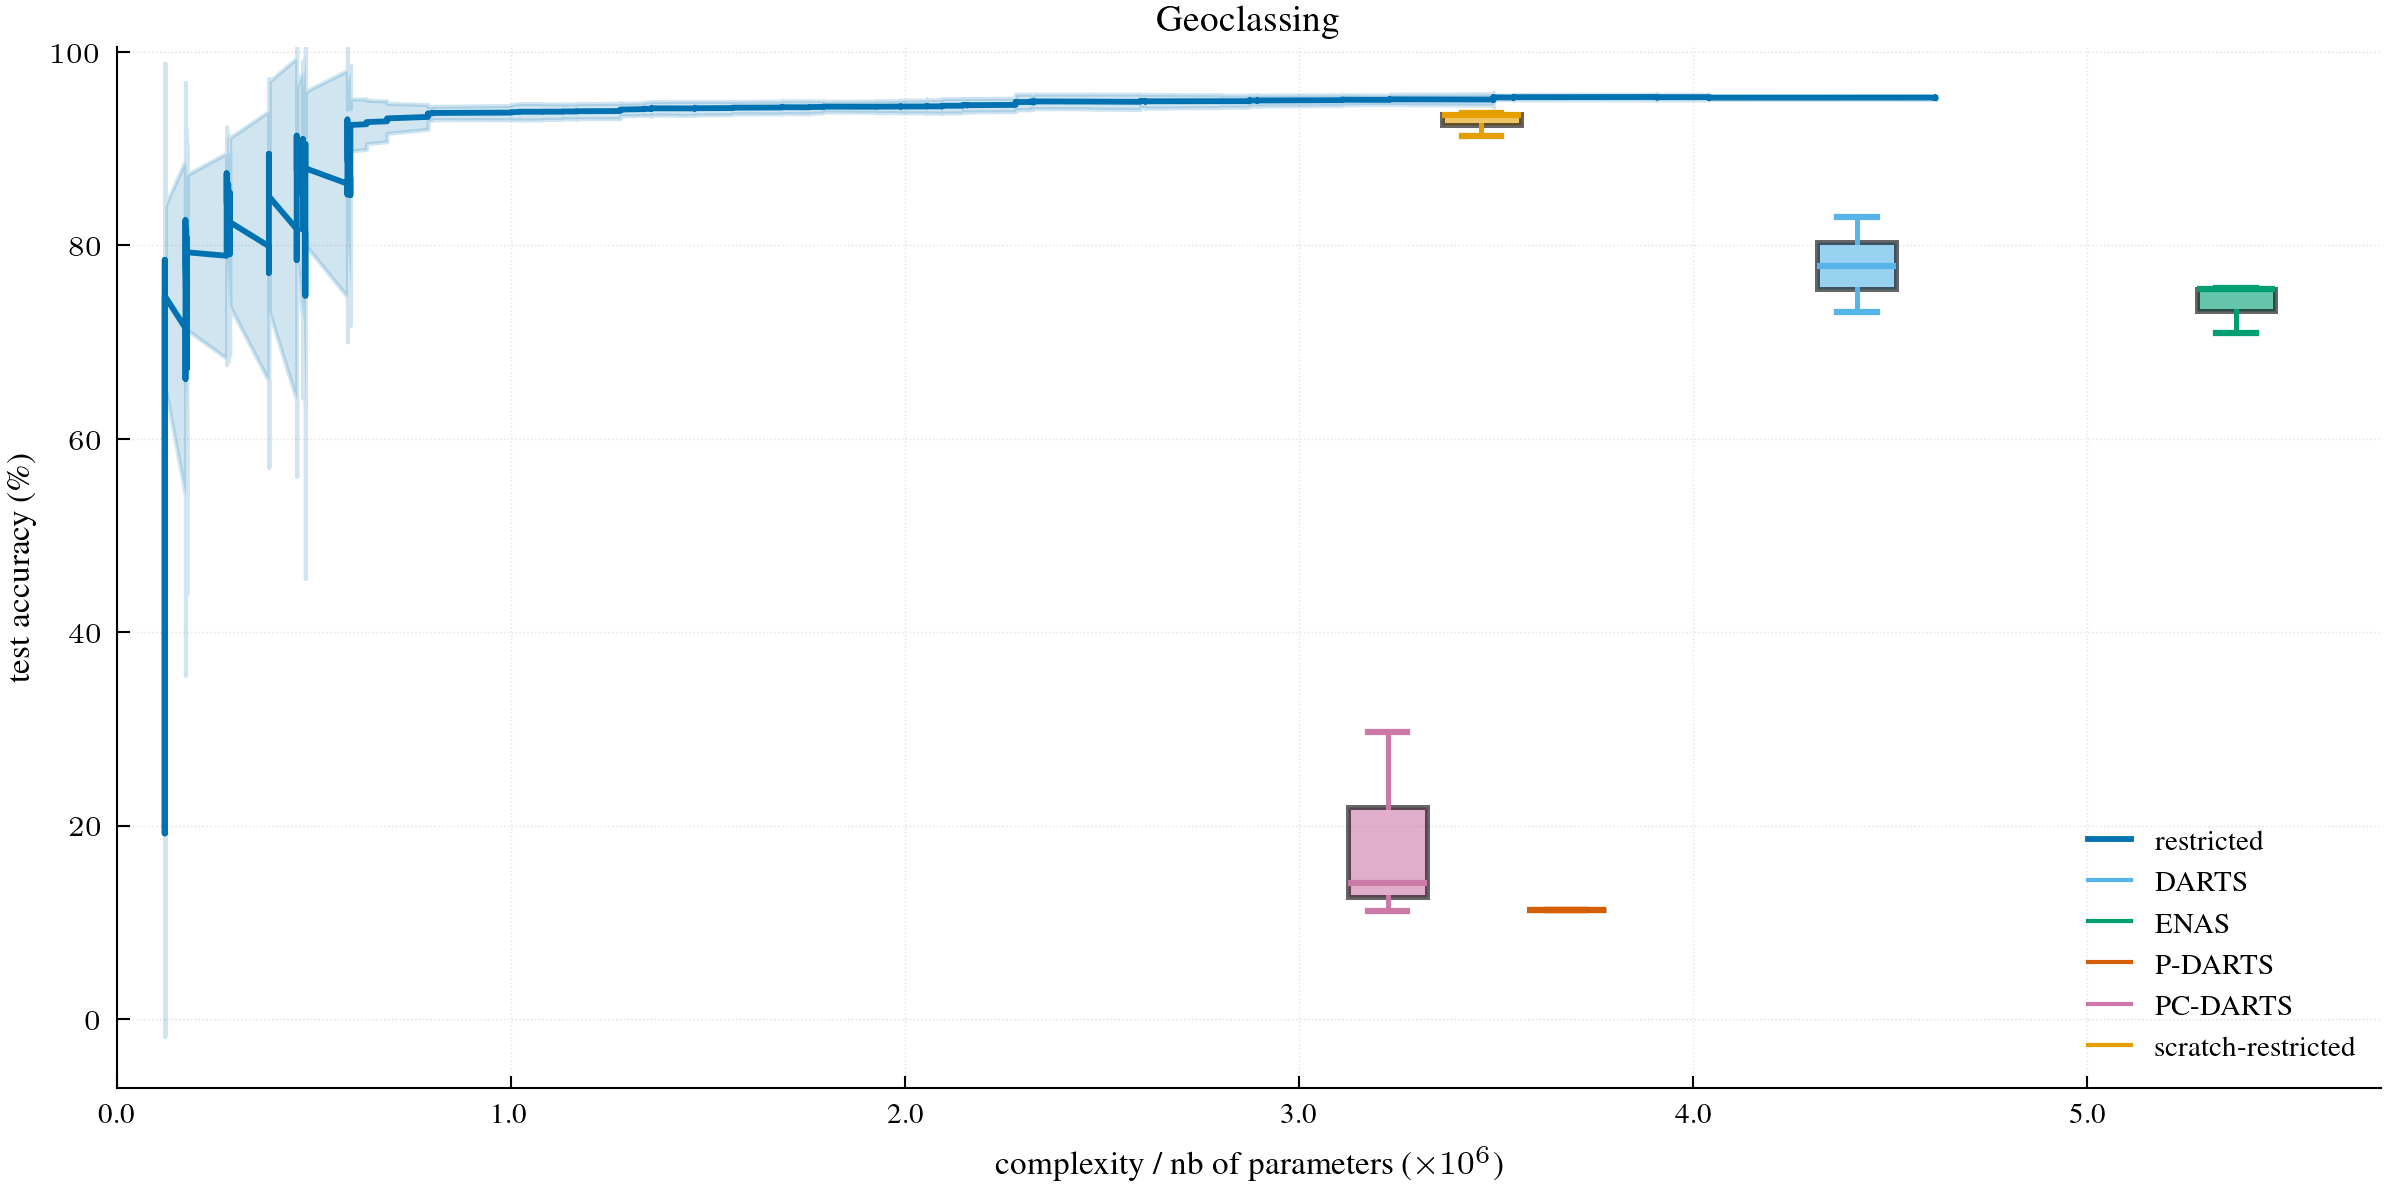

In [194]:
fig, ax = plot_metrics_with_ci_step({k:v for k,v in groups.items() if "scratch" not in k}, 
        metric_keys=["training/test accuracy"],
        title="Geoclassing",
        step="complexity/nb of parameters", step_key="epoch",
        smooth_window=4,
)
myHandle, extra_labels = add_box(ax, nas_groups["geoclassing"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/geoclassing.png")

DARTS
Parameters: [4188648, 4216512, 4840320]
Mean parameters: 4415160.0
Values: [73.1344989266699, 82.92766542124647, 77.83110501929401] 

ENAS
Parameters: [5377390, 5377390, 5377390]
Mean parameters: 5377390.0
Values: [70.88332761534144, 75.47708832840281, 75.55707918223129] 

P-DARTS
Parameters: [3823246, 3371158, 3841822]
Mean parameters: 3678742.0
Values: [11.233001942199213, 11.312992800822762, 11.233001942199213] 

PC-DARTS
Parameters: [2912158, 3603142, 3158614]
Mean parameters: 3224638.0
Values: [14.101245571662188, 11.130156552991844, 29.66518112106768] 

scratch-restricted
Parameters: [2281047, 3493229, 4614518, 3362210]
Mean parameters: 3437751.0
Values: [93.71500611305235, 93.49788427352904, 93.5778796672821, 93.63501071929932] 



/tmp/ipykernel_7813/2890554414.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


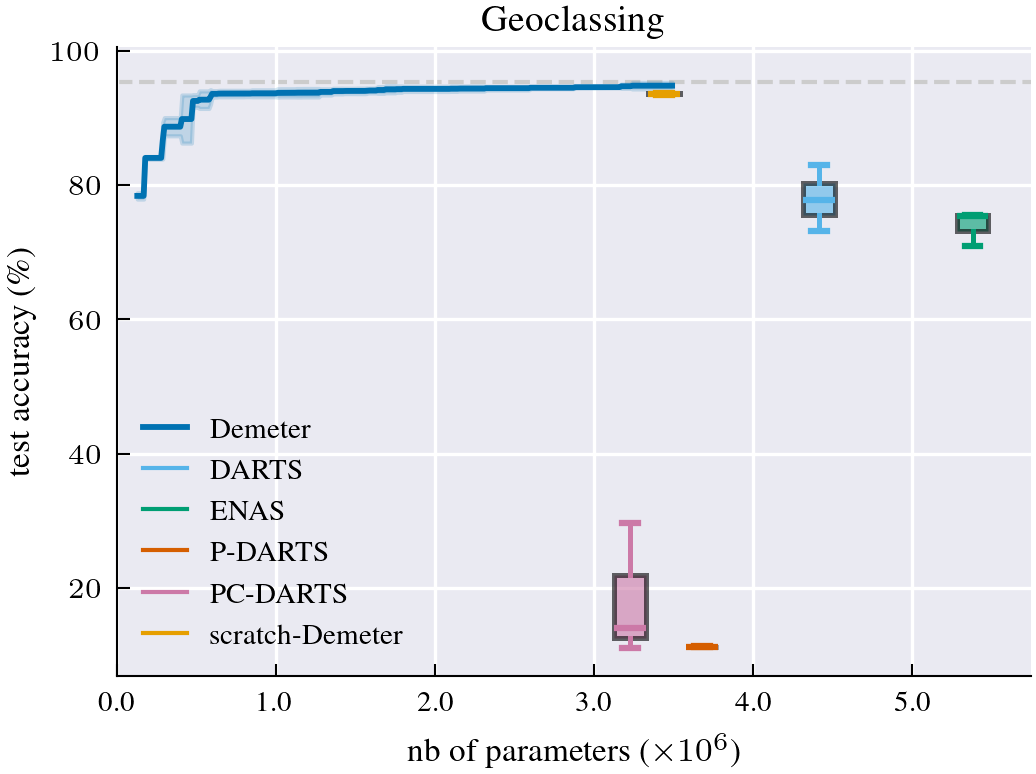

In [70]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k}, 
        metric_keys=["training/test accuracy"],
        title="Geoclassing",
        step="complexity/nb of parameters", step_key="epoch",
        # smooth_window=4,
        bin_size=10_000,
        use_max=True,
        use_cummax=True,
)
myHandle, extra_labels = add_box(ax, nas_groups["geoclassing"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/geoclassing_bin.png")

In [93]:
chesseract_runs = load_runs("Strategies-Chesseract-scalar", entity=ENTITY,
                        filters={
                              "config.growth.neuron_selection_threshold.value": 0.00028,
                              "config.training.es_abs_delta.value": 0.00122,
                              "group": {"$in" : ["restricted", "scratch-restricted"]},
                              # "group": None,
                              "config.model.init_hidden_channels.value": 64,
                              "config.growth.steps.value": 60,
                        }
)
groups = group_df(chesseract_runs, by="group")

Found 6 runs in 'Strategies-Chesseract-scalar'


In [87]:
groups

{None: [<Run stella_douka-personal/Strategies-Chesseract-scalar/amkayoxj (finished)>,
  <Run stella_douka-personal/Strategies-Chesseract-scalar/ccs9xuai (finished)>,
  <Run stella_douka-personal/Strategies-Chesseract-scalar/ve0d76bd (finished)>]}

In [94]:
maximums = []
for run in groups["restricted"]:
    hist = run.history(keys=["epoch", "training/test accuracy"])
    total_epochs = hist["epoch"].max()
    max_accuracy = hist.loc[hist["training/test accuracy"].idxmax()]
    maximums.append(max_accuracy["training/test accuracy"]*100)
    print(run.name)
    print(total_epochs)
    print(max_accuracy)
    print("In the final epochs?", total_epochs - max_accuracy['epoch'] < 200)
    print()
np.median(maximums), np.std(maximums)

pretty-water-12
589
_step                     102.000000
epoch                      15.000000
training/test accuracy      0.656166
Name: 13, dtype: float64
In the final epochs? False

deep-morning-13
610
_step                     72.000000
epoch                     10.000000
training/test accuracy     0.658666
Name: 8, dtype: float64
In the final epochs? False

fluent-dragon-14
660
_step                     96.000000
epoch                     14.000000
training/test accuracy     0.664766
Name: 9, dtype: float64
In the final epochs? False



(65.86658954620361, 0.36123869816237036)

In [92]:
maximums = []
for run in groups[None]:
    hist = run.history(keys=["epoch", "training/test accuracy"])
    total_epochs = hist["epoch"].max()
    max_accuracy = hist.loc[hist["training/test accuracy"].idxmax()]
    maximums.append(max_accuracy["training/test accuracy"]*100)
    print(run.name)
    print(total_epochs)
    print(max_accuracy)
    print("In the final epochs?", total_epochs - max_accuracy['epoch'] < 200)
    print()
np.median(maximums), np.std(maximums)

rose-moon-1
1077
_step                     1653.000000
epoch                      198.000000
training/test accuracy       0.662866
Name: 90, dtype: float64
In the final epochs? False

magic-sea-1
621
_step                     483.000000
epoch                      64.000000
training/test accuracy      0.636764
Name: 46, dtype: float64
In the final epochs? False

volcanic-blaze-1
882
_step                     1036.000000
epoch                      127.000000
training/test accuracy       0.648565
Name: 69, dtype: float64
In the final epochs? False



(64.8564875125885, 1.0672625286745103)

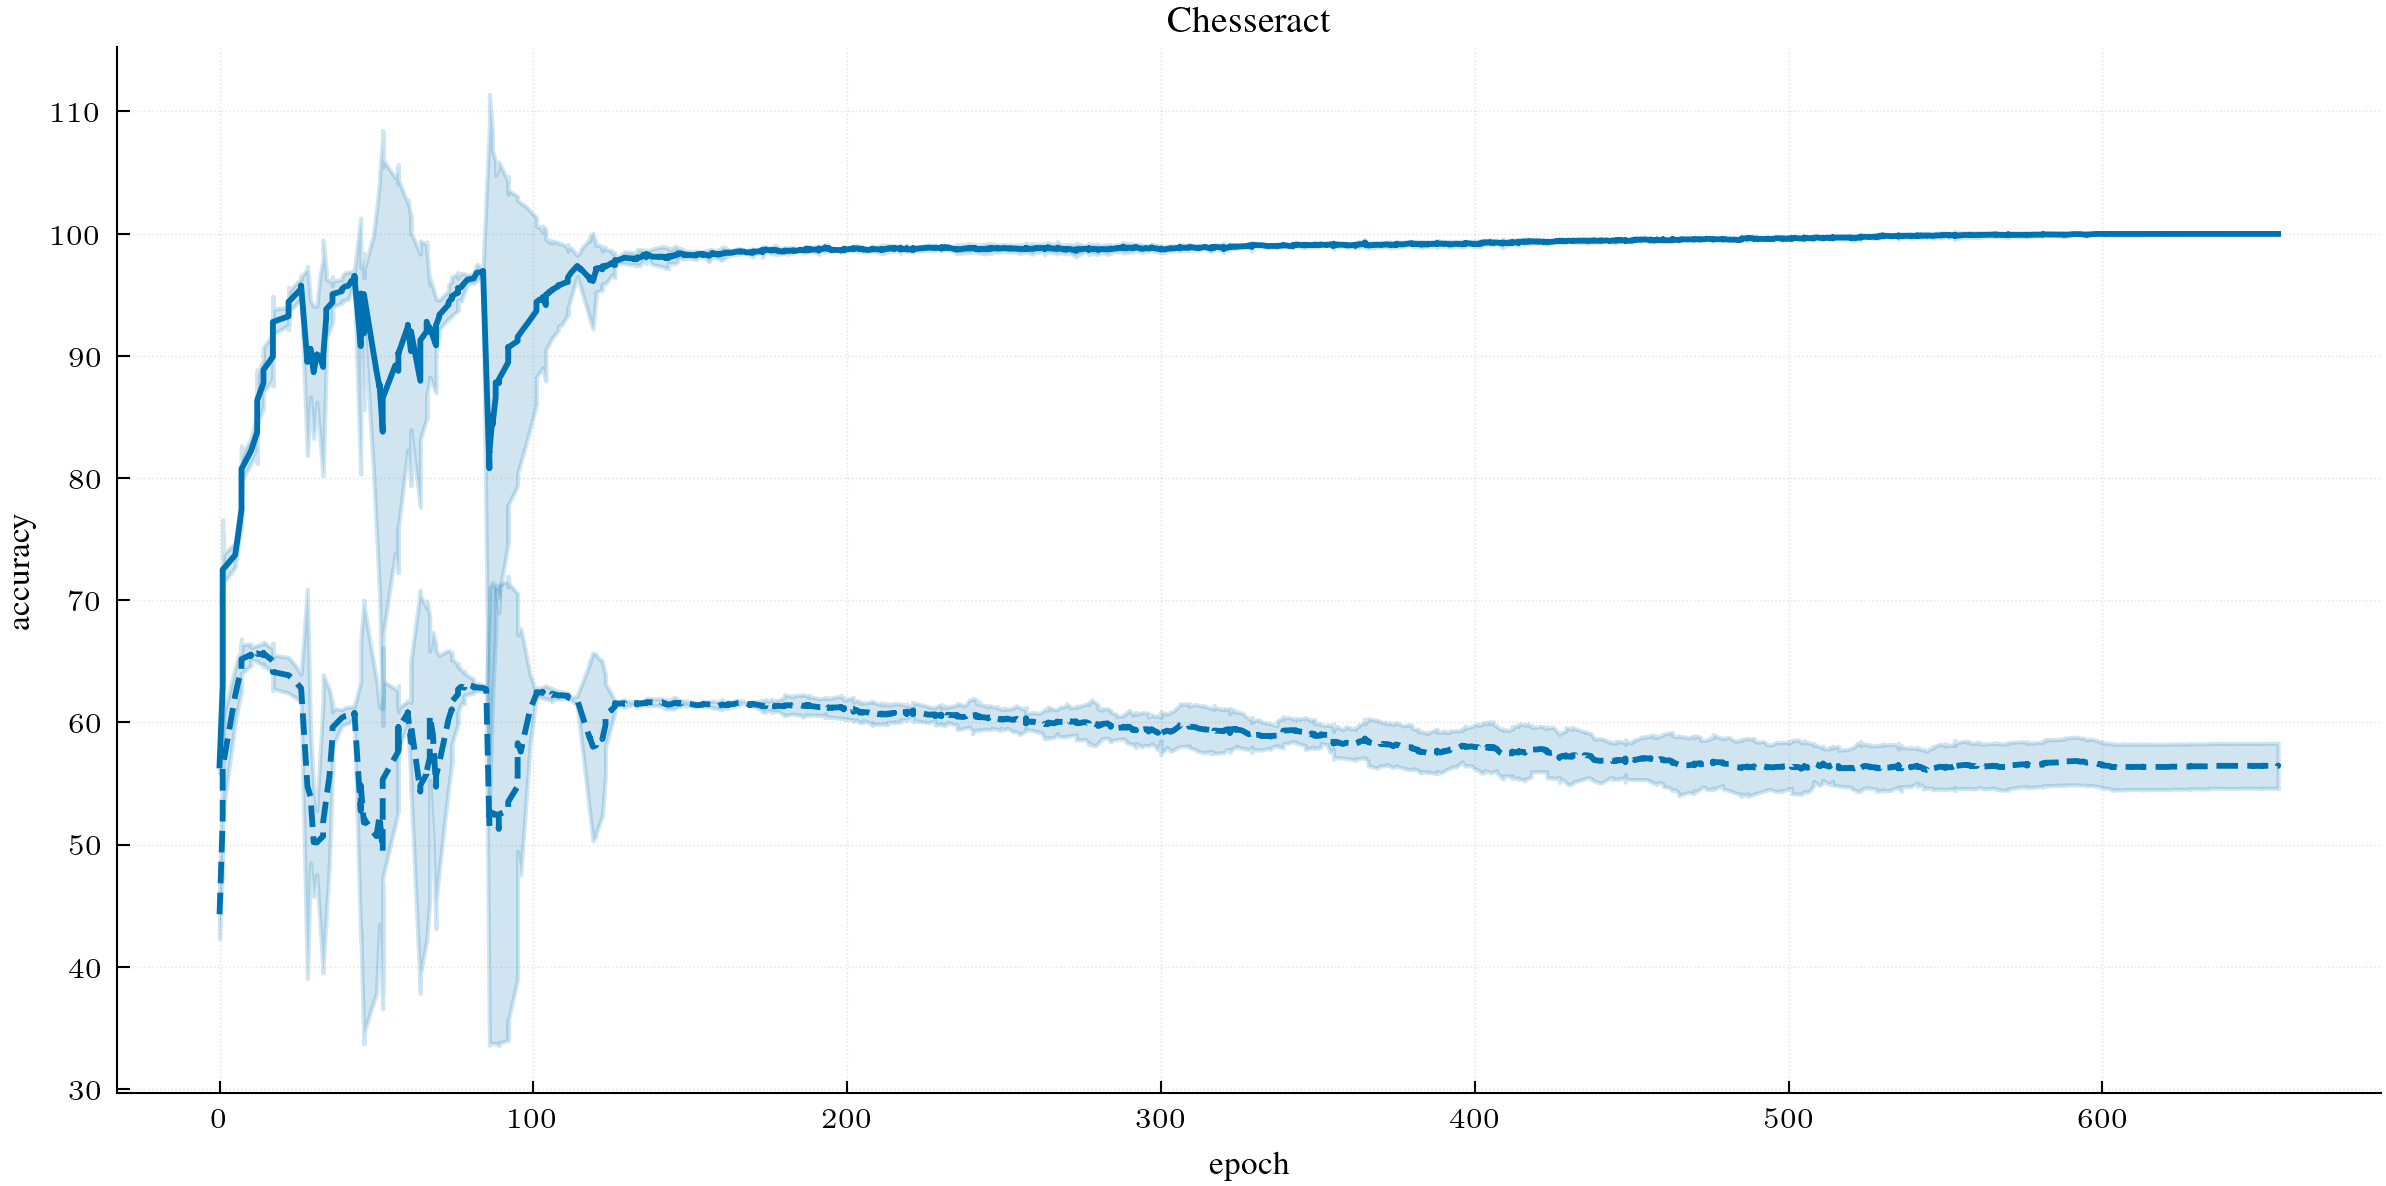

In [99]:
fig, ax = plot_metrics_with_ci_step(groups, metric_keys=["training/train accuracy", "training/test accuracy"], title="Chesseract")

DARTS
Parameters: [4483894, 4444798, 4680454]
Mean parameters: 4536382.0
Values: [59.89598960253654, 59.17591759652802, 60.016001603736655] 

P-DARTS
Parameters: [3844803, 3815211, 3811755]
Mean parameters: 3823923.0
Values: [60.13601360136014, 60.076007596945004, 59.57595759385204] 

PC-DARTS
Parameters: [1981155, 1461243, 1695819]
Mean parameters: 1712739.0
Values: [57.96579657584289, 57.45574557455746, 57.31573157124977] 

ENAS
Parameters: [5381683, 5381683, 5381683]
Mean parameters: 5381683.0
Values: [56.815681566249275, 57.52575257525753, 56.845684568456846] 



/tmp/ipykernel_147109/852388698.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


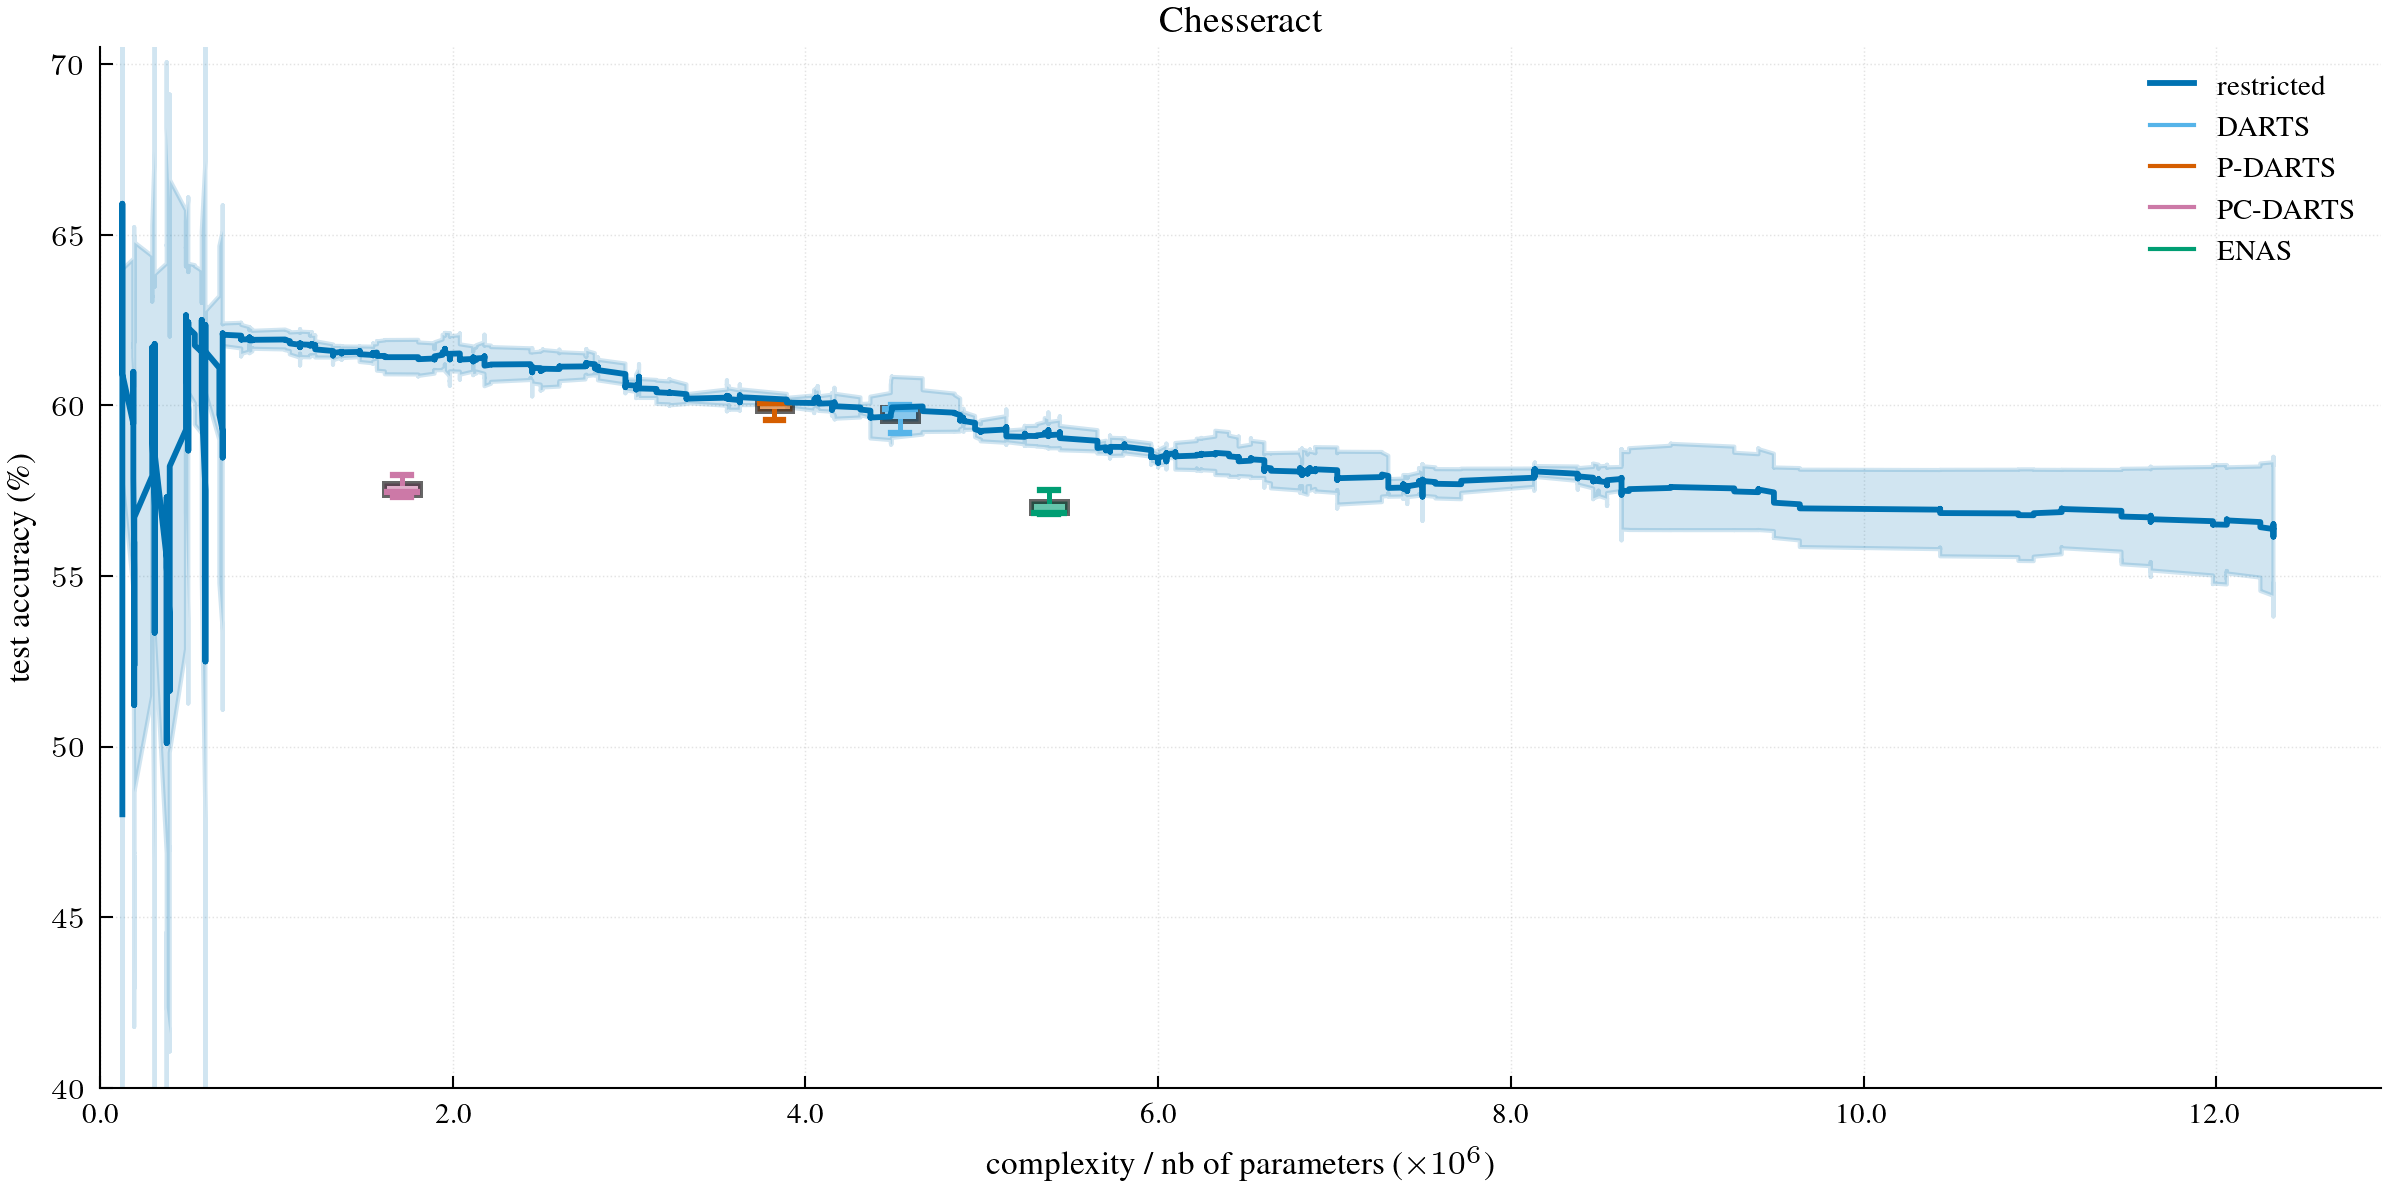

In [116]:
fig, ax = plot_metrics_with_ci_step(groups, metric_keys=["training/test accuracy"],
        title="Chesseract",
        step="complexity/nb of parameters", step_key="epoch",
        smooth_window=4,
)

myHandle, extra_labels = add_box(ax, nas_groups["chesseract"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(bottom=40, top=70.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"complexity / nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/chesseract.png")

/tmp/ipykernel_7813/2869924482.py:16: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(values, axis=1)
/home/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_7813/1466090416.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


DARTS
Parameters: [4483894, 4444798, 4680454]
Mean parameters: 4536382.0
Values: [59.89598960253654, 59.17591759652802, 60.016001603736655] 

P-DARTS
Parameters: [4323243.0, 4135755.0, 3937683.0]
Mean parameters: 4132227.0
Values: [60.04600459664498, 60.25602560065272, 60.84608460846085] 

PC-DARTS
Parameters: [1584795, 1905987, 1664067]
Mean parameters: 1718283.0
Values: [56.13561356135614, 58.13581357754305, 58.2358235804507] 

ENAS
Parameters: [5381683, 5381683, 5381683]
Mean parameters: 5381683.0
Values: [56.815681566249275, 57.52575257525753, 56.845684568456846] 

scratch-restricted
Parameters: [193597, 194282, 188802]
Mean parameters: 192227.0
Values: [61.03610396385193, 60.29602885246277, 61.70617341995239] 



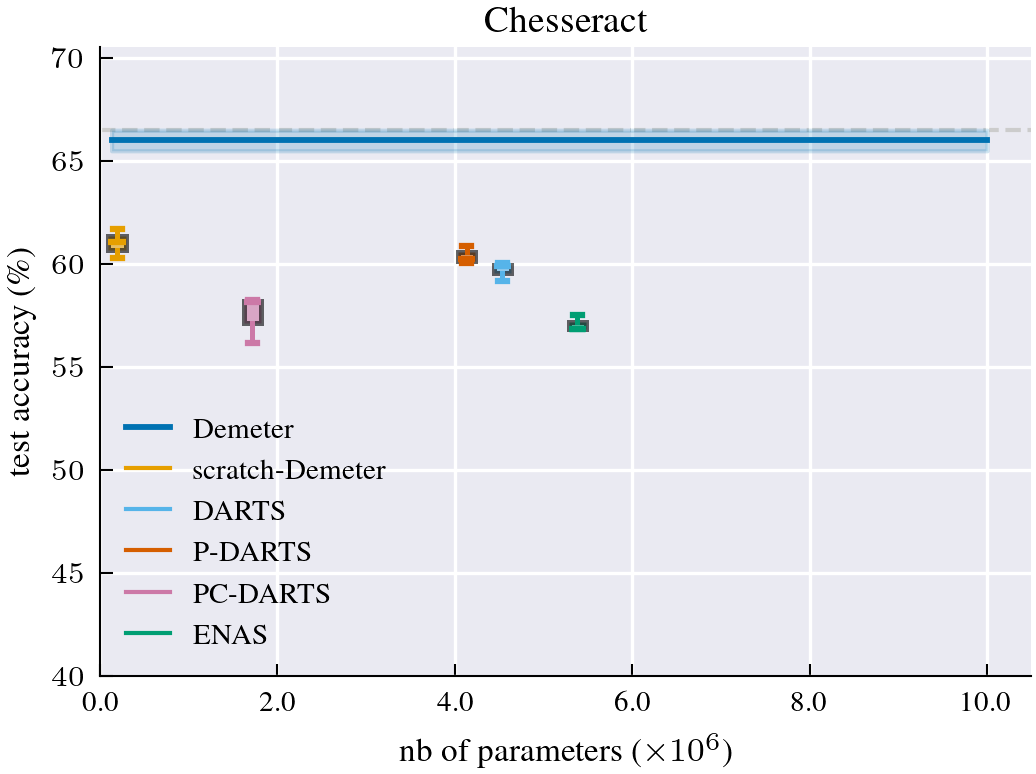

In [96]:
fig, ax = plot_metrics_with_ci_fin(groups, metric_keys=["training/test accuracy"],
        title="Chesseract",
        step="complexity/nb of parameters", step_key="epoch",
        # smooth_window=4,
        bin_size=10_000,
        use_max=True,
        use_cummax=True,
)

myHandle, extra_labels = add_box(ax, nas_groups["chesseract"], pos="training/nb of parameters", width=200_000)
myHandle1, extra_labels1 = add_box(ax, {k:v for k,v in groups.items() if "scratch" in k}, pos="complexity/nb of parameters", width=200_000)
myHandle.extend(myHandle1)
extra_labels.extend(extra_labels1)
legend(ax, extra_lines=myHandle, extra_labels=extra_labels, frameon=False)
ax.set_ylim(bottom=40, top=70.5)
ax.set_xlim(left=0, right=None)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(_fmt_params))
ax.set_xlabel(r"nb of parameters ($\times 10^6$)")
ax.set_ylabel("test accuracy (\%)")

fig.show()
fig.savefig("../temp/plots/chesseract_bin.png")

/tmp/ipykernel_7813/1355584920.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


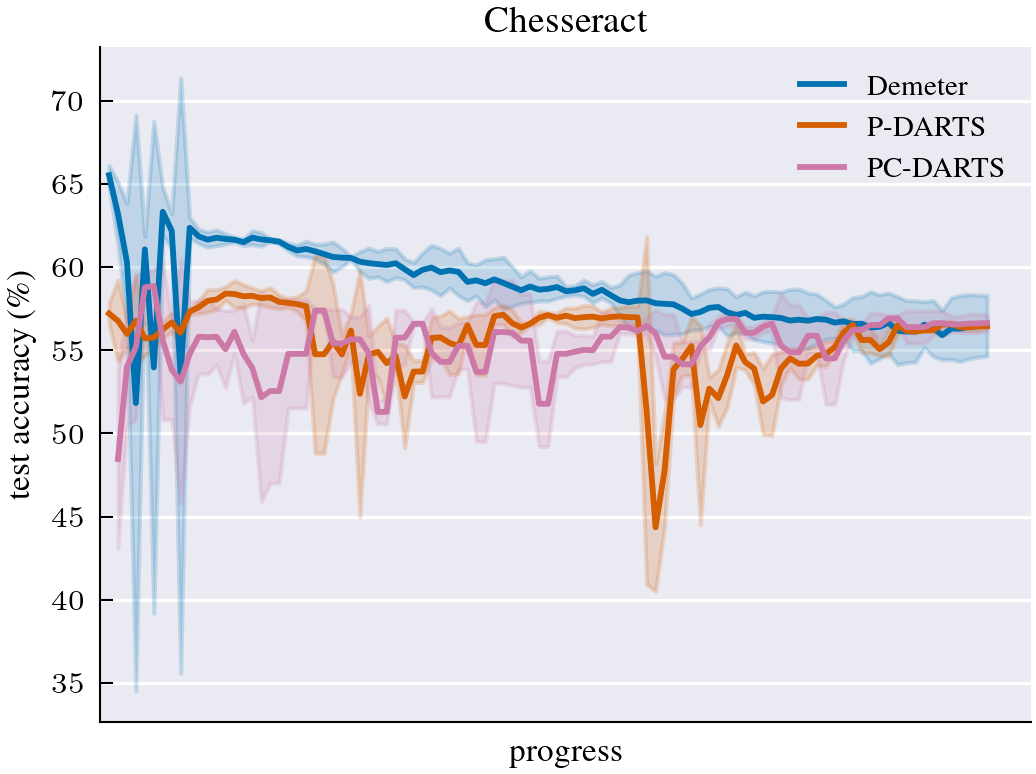

In [97]:
fig, ax = plot_metrics_with_ci_fin({k:v for k,v in groups.items() if "scratch" not in k},
        metric_keys=["training/test accuracy"],
        step="_runtime", title="Chesseract", step_key="epoch",
        # smooth_window=4,
        bin_size=100,
        # logscale=True,
        use_max=True,
        normalize_x=True,
        guides=False,
)
fig, ax = plot_metrics_with_ci_fin(nas_groups["chesseract"],
        ax=ax,
        title="Chesseract",
        metric_keys=["search/test accuracy"],
        step="_runtime", step_key="search epoch",
        bin_size=100,
        use_max=True,
        normalize_x=True,
        guides=False,
)
legend(ax, frameon=False)
# ax.set_ylim(top=100.5)
ax.set_xlim(left=0, right=None)
ax.set_xlabel("progress")
ax.set_ylabel("test accuracy (\%)")
ax.set_xticks([])

fig.show()
fig.savefig("../temp/plots/chesseract_1shot.png")

## One-shot

### Metric vs metric

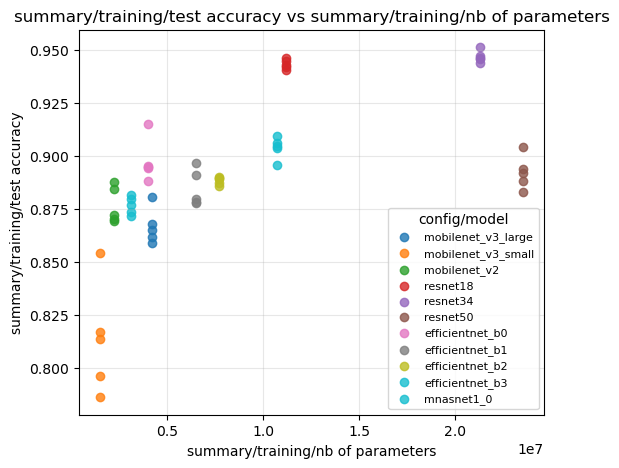

In [35]:
# # One point per step across all runs: train loss vs val loss, coloured by run
# plot_metric_vs_metric(
#     runs,
#     x_metric="training/train loss",
#     y_metric="training/val loss",
#     color_by="run_name",
#     source="history",
#     samples=200,
# )
# plt.show()

# One point per run: final train acc vs final val acc, coloured by a config key
plot_metric_vs_metric(
    summary_df,
    x_metric="summary/training/nb of parameters",
    y_metric="summary/training/test accuracy",
    color_by="config/model",
    source="summary",
)
plt.show()

  'training/val accuracy' not found in run 'clear-fog-72', skipping.
  'training/val accuracy' not found in run 'restful-puddle-74', skipping.
  'training/val accuracy' not found in run 'cool-deluge-73', skipping.
  'training/val accuracy' not found in run 'rare-night-74', skipping.
  'training/val accuracy' not found in run 'rural-blaze-74', skipping.
  'training/val accuracy' not found in run 'daily-hill-77', skipping.
  'training/val accuracy' not found in run 'twilight-valley-77', skipping.
  'training/val accuracy' not found in run 'usual-terrain-77', skipping.
  'training/val accuracy' not found in run 'robust-pond-81', skipping.
  'training/val accuracy' not found in run 'ancient-sun-77', skipping.
  'training/val accuracy' not found in run 'soft-moon-82', skipping.
  'training/val accuracy' not found in run 'decent-feather-83', skipping.
  'training/val accuracy' not found in run 'legendary-glade-83', skipping.
  'training/val accuracy' not found in run 'feasible-blaze-85', ski

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  'training/val accuracy' not found in run '8-bit-crown-126', skipping.
  'training/val loss' not found in run 'clear-fog-72', skipping.
  'training/val loss' not found in run 'restful-puddle-74', skipping.
  'training/val loss' not found in run 'cool-deluge-73', skipping.
  'training/val loss' not found in run 'rare-night-74', skipping.
  'training/val loss' not found in run 'rural-blaze-74', skipping.
  'training/val loss' not found in run 'daily-hill-77', skipping.
  'training/val loss' not found in run 'twilight-valley-77', skipping.
  'training/val loss' not found in run 'usual-terrain-77', skipping.
  'training/val loss' not found in run 'robust-pond-81', skipping.
  'training/val loss' not found in run 'ancient-sun-77', skipping.
  'training/val loss' not found in run 'soft-moon-82', skipping.
  'training/val loss' not found in run 'decent-feather-83', skipping.
  'training/val loss' not found in run 'legendary-glade-83', skipping.
  'training/val loss' not found in run 'feasibl

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


  'training/val loss' not found in run '8-bit-crown-126', skipping.


/tmp/ipykernel_15520/372750596.py:58: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  fig.tight_layout()


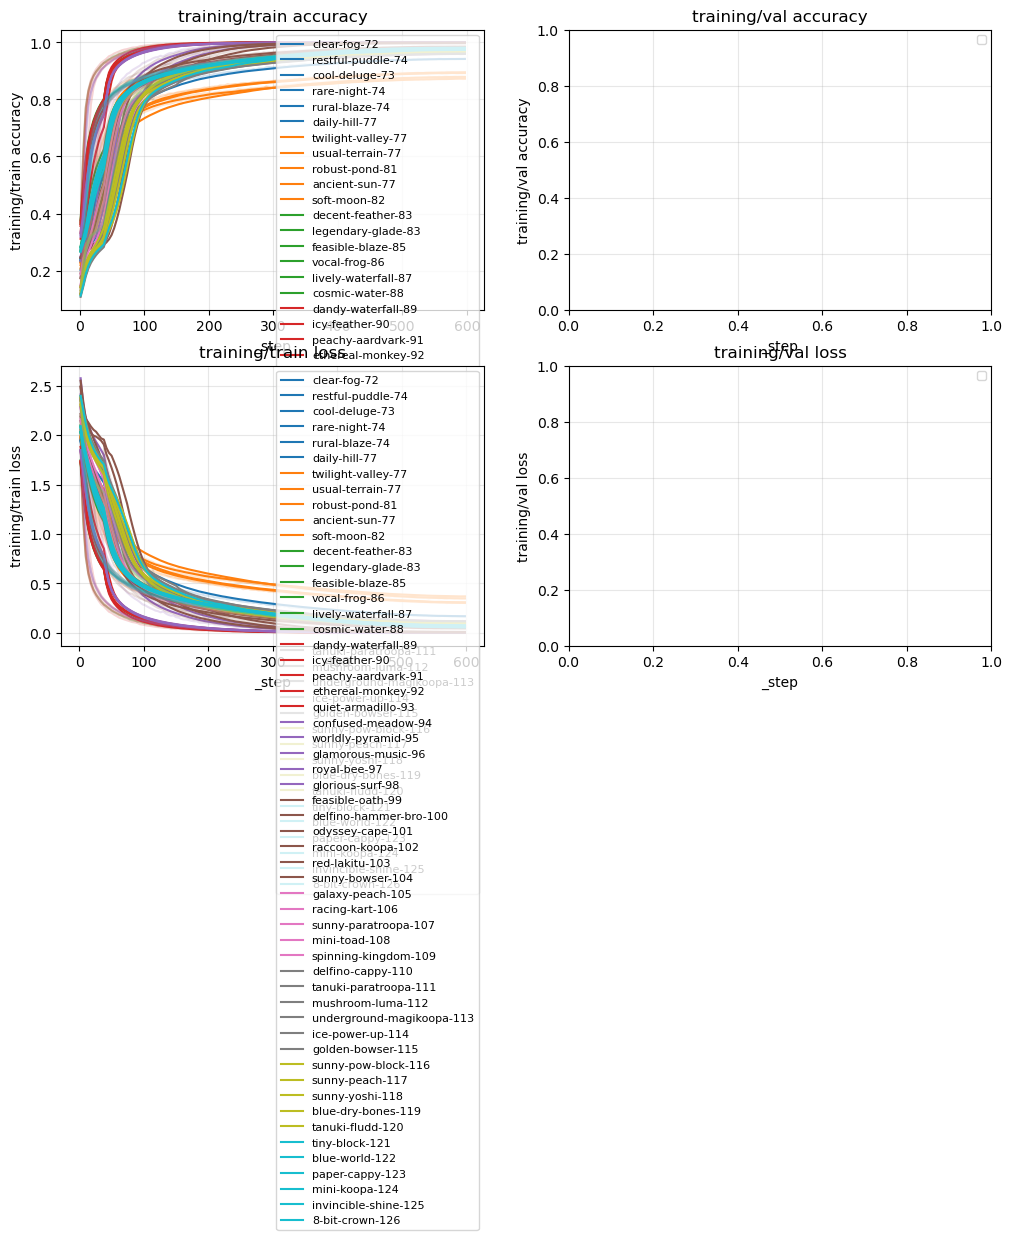

In [23]:
# Plot training/validation accuracy for all runs
plot_metrics(
    runs,
    metrics=["training/train accuracy", "training/test accuracy", "training/train loss", "training/test loss"],
    x="_step",
    smooth=10,
)
plt.show()

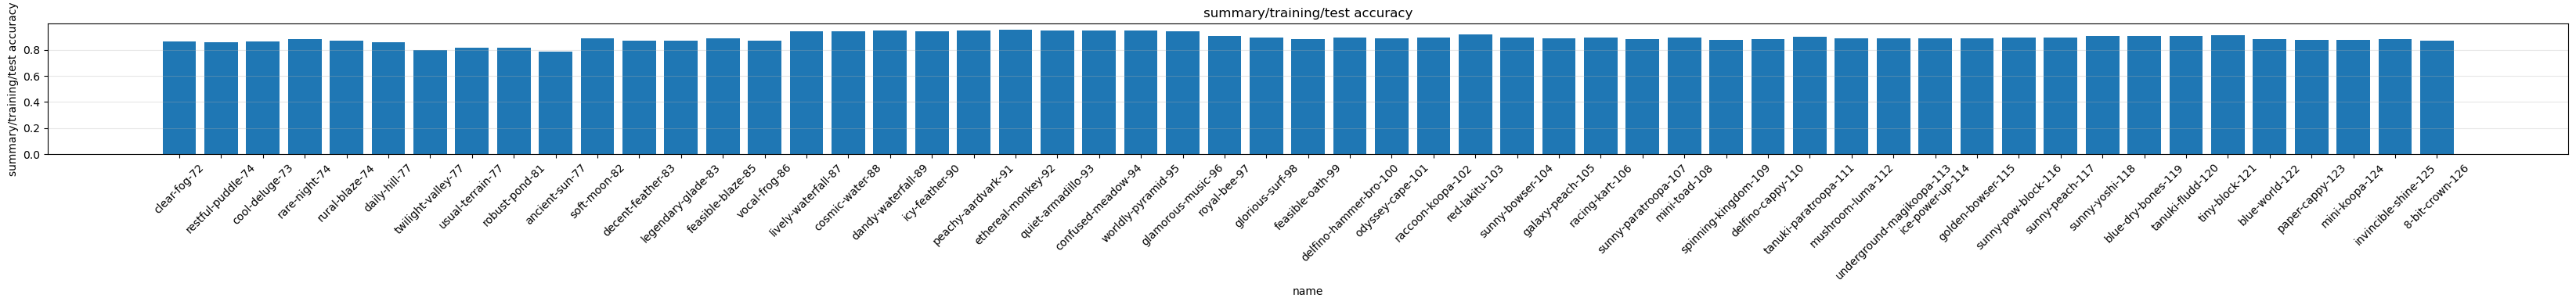

In [24]:
# Compare final validation accuracy across runs
plot_summary_bar(summary_df, metric_col="summary/training/test accuracy")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Found 0 runs in 'SmallBenchmarks'


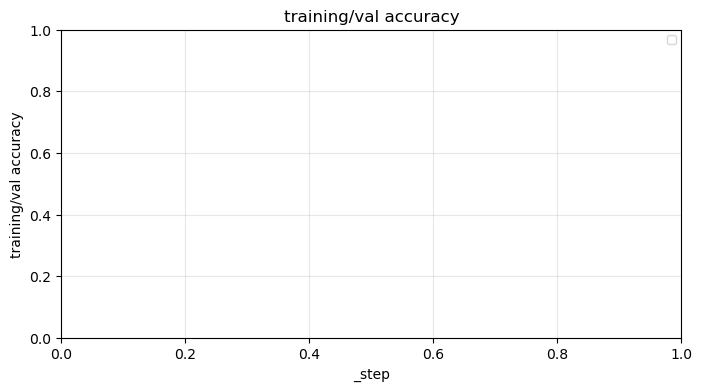

In [25]:
# Filter to a subset of runs by tag and plot a single metric
tagged_runs = load_runs(PROJECT, entity=ENTITY, tags=["grow"])
plot_metric(tagged_runs, metric="training/val accuracy", smooth=5)
plt.show()